In [1]:
#import kibraries

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
#load dataset

movies = pd.read_csv("data/movie_metadata.csv")
tags = pd.read_csv("data/tags.csv")

print("Movies shape:", movies.shape)
print("Tags shape:", tags.shape)

print("\nMovies:")
print(movies.head())

print("\nTags:")
print(tags.head())

Movies shape: (87585, 5)
Tags shape: (2000072, 4)

Movies:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  imdbId   tmdbId  
0  Adventure|Animation|Children|Comedy|Fantasy  114709    862.0  
1                   Adventure|Children|Fantasy  113497   8844.0  
2                               Comedy|Romance  113228  15602.0  
3                         Comedy|Drama|Romance  114885  31357.0  
4                                       Comedy  113041  11862.0  

Tags:
   userId  movieId          tag   timestamp
0      22    26479  Kevin Kline  1583038886
1      22    79592     misogyny  1581476297
2      22   247150   acrophobia  1622483469
3      34     2174        music  1249808064
4      34     217

In [3]:
# Keep only the columns needed for Content-Based Filtering

movies = movies[["movieId", "title", "genres"]].copy()
tags = tags[["movieId", "tag"]].copy()

print("Movies shape:", movies.shape)
print("Tags shape:", tags.shape)

print("\nMovies columns:")
print(movies.columns.tolist())

print("\nTags columns:")
print(tags.columns.tolist())

Movies shape: (87585, 3)
Tags shape: (2000072, 2)

Movies columns:
['movieId', 'title', 'genres']

Tags columns:
['movieId', 'tag']


In [4]:
# Remove rows with missing tags
tags = tags.dropna(subset=["tag"])

# Convert tags to string and remove extra spaces
tags["tag"] = tags["tag"].astype(str).str.strip()

print("Tags after cleaning:", tags.shape)

Tags after cleaning: (2000055, 2)


In [5]:
# Combine all tags belonging to the same movie

tags_grouped = (
    tags.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)

print("Grouped tags shape:", tags_grouped.shape)

tags_grouped.head()

Grouped tags shape: (51323, 2)


,movieId,tag
0,1,children Disney animation children Disney Disn...
1,2,Robin Williams fantasy Robin Williams time tra...
2,3,comedinha de velhinhos engraÃƒÂ§ada comedinha ...
3,4,characters slurs based on novel or book chick ...
4,5,Fantasy pregnancy remake family Steve Martin s...


In [6]:
# Merge movie metadata with aggregated tags

movies_cb = movies.merge(
    tags_grouped,
    on="movieId",
    how="left"
)

print("Combined dataset shape:", movies_cb.shape)

movies_cb.head()

Combined dataset shape: (87585, 4)


,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,children Disney animation children Disney Disn...
1,2,Jumanji (1995),Adventure|Children|Fantasy,Robin Williams fantasy Robin Williams time tra...
2,3,Grumpier Old Men (1995),Comedy|Romance,comedinha de velhinhos engraÃƒÂ§ada comedinha ...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,characters slurs based on novel or book chick ...
4,5,Father of the Bride Part II (1995),Comedy,Fantasy pregnancy remake family Steve Martin s...


In [7]:
# Replace missing genres and tags with empty strings

movies_cb["genres"] = movies_cb["genres"].fillna("")
movies_cb["tag"] = movies_cb["tag"].fillna("")

In [8]:
print("Movies without tags:", (movies_cb["tag"] == "").sum())

Movies without tags: 36262


In [9]:
#clean genres |
movies_cb["genres"] = movies_cb["genres"].str.replace(
    "|",
    " ",
    regex=False
)

In [10]:
# create combined content

movies_cb["content"] = (
    movies_cb["genres"] + " " + movies_cb["tag"]
)

In [11]:
# Reset index for consistent positional indexing
movies_cb = movies_cb.reset_index(drop=True)

print(movies_cb.index[:10])

RangeIndex(start=0, stop=10, step=1)


In [12]:
movies_cb[
    ["movieId", "title", "genres", "tag", "content"]
].head(10)

,movieId,title,genres,tag,content
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,children Disney animation children Disney Disn...,Adventure Animation Children Comedy Fantasy ch...
1,2,Jumanji (1995),Adventure Children Fantasy,Robin Williams fantasy Robin Williams time tra...,Adventure Children Fantasy Robin Williams fant...
2,3,Grumpier Old Men (1995),Comedy Romance,comedinha de velhinhos engraÃƒÂ§ada comedinha ...,Comedy Romance comedinha de velhinhos engraÃƒÂ...
3,4,Waiting to Exhale (1995),Comedy Drama Romance,characters slurs based on novel or book chick ...,Comedy Drama Romance characters slurs based on...
4,5,Father of the Bride Part II (1995),Comedy,Fantasy pregnancy remake family Steve Martin s...,Comedy Fantasy pregnancy remake family Steve M...
5,6,Heat (1995),Action Crime Thriller,atmospheric dialogue Tumey's DVDs atmospheric ...,Action Crime Thriller atmospheric dialogue Tum...
6,7,Sabrina (1995),Comedy Romance,as good maybe better than original great cast ...,Comedy Romance as good maybe better than origi...
7,8,Tom and Huck (1995),Adventure Children,Library System based on a book Mark Twain 19th...,Adventure Children Library System based on a b...
8,9,Sudden Death (1995),Action,Action Jean-Claude Van Damme Can't remember ac...,Action Action Jean-Claude Van Damme Can't reme...
9,10,GoldenEye (1995),Action Adventure Thriller,james bond Tumey's DVDs 007 Bond casual sex es...,Action Adventure Thriller james bond Tumey's D...


In [13]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=2,
    max_df=0.95
)

tfidf_matrix = tfidf.fit_transform(
    movies_cb["content"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (87585, 28306)


In [14]:
# TF-IDF for Genres

genre_tfidf = TfidfVectorizer(
    stop_words="english"
)

genre_matrix = genre_tfidf.fit_transform(
    movies_cb["genres"]
)

print("Genre TF-IDF matrix shape:", genre_matrix.shape)

Genre TF-IDF matrix shape: (87585, 23)


In [15]:
# TF-IDF for Tags

tag_tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=2,
    max_df=0.95
)

tag_matrix = tag_tfidf.fit_transform(
    movies_cb["tag"]
)

print("Tag TF-IDF matrix shape:", tag_matrix.shape)

Tag TF-IDF matrix shape: (87585, 28305)


In [16]:
def get_weighted_recommendations(
    title,
    top_n=10,
    genre_weight=0.7,
    tag_weight=0.3
):
    
    # Check whether the movie exists
    if title not in movies_cb["title"].values:
        raise ValueError(
            f"Movie '{title}' was not found."
        )
    
    # Get movie index
    idx = movies_cb.index[
        movies_cb["title"] == title
    ][0]
    
    # Calculate genre similarity
    genre_similarity = cosine_similarity(
        genre_matrix[idx],
        genre_matrix
    ).flatten()
    
    # Calculate tag similarity
    tag_similarity = cosine_similarity(
        tag_matrix[idx],
        tag_matrix
    ).flatten()
    
    # Weighted similarity
    final_similarity = (
        genre_weight * genre_similarity
        +
        tag_weight * tag_similarity
    )
    
    # Sort by final similarity
    similar_indices = final_similarity.argsort()[::-1]
    
    # Remove input movie
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ]
    
    # Top N
    top_indices = similar_indices[:top_n]
    
    # Create recommendation dataframe
    recommendations = movies_cb.iloc[
        top_indices
    ][
        ["movieId", "title", "genres"]
    ].copy()
    
    recommendations["genre_similarity"] = [
        genre_similarity[i]
        for i in top_indices
    ]
    
    recommendations["tag_similarity"] = [
        tag_similarity[i]
        for i in top_indices
    ]
    
    recommendations["similarity"] = [
        final_similarity[i]
        for i in top_indices
    ]
    
    return recommendations

In [17]:
get_weighted_recommendations(
    "Toy Story (1995)",
    top_n=10,
    genre_weight=0.7,
    tag_weight=0.3
)

,movieId,title,genres,genre_similarity,tag_similarity,similarity
3021,3114,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy,1.00000,0.889389,0.966817
4781,4886,"Monsters, Inc. (2001)",Adventure Animation Children Comedy Fantasy,1.00000,0.710757,0.913227
30501,136016,The Good Dinosaur (2015),Adventure Animation Children Comedy Fantasy,1.00000,0.510626,0.853188
2264,2355,"Bug's Life, A (1998)",Adventure Animation Children Comedy,0.86603,0.806327,0.848119
22647,115879,Toy Story Toons: Small Fry (2011),Adventure Animation Children Comedy Fantasy,1.00000,0.483739,0.845122
75375,247988,Luca (2021),Adventure Animation Children Comedy Fantasy,1.00000,0.456165,0.836849
2203,2294,Antz (1998),Adventure Animation Children Comedy Fantasy,1.00000,0.404146,0.821244
6259,6377,Finding Nemo (2003),Adventure Animation Children Comedy,0.86603,0.707163,0.818370
69923,225173,Soul (2020),Adventure Animation Children Comedy Fantasy,1.00000,0.356125,0.806838
3913,4016,"Emperor's New Groove, The (2000)",Adventure Animation Children Comedy Fantasy,1.00000,0.335402,0.800621


In [18]:
get_weighted_recommendations(
    "Dark Knight, The (2008)",
    top_n=10,
    genre_weight=0.7,
    tag_weight=0.3
)

,movieId,title,genres,genre_similarity,tag_similarity,similarity
10004,33794,Batman Begins (2005),Action Crime IMAX,0.975205,0.722142,0.899286
17469,91529,"Dark Knight Rises, The (2012)",Action Adventure Crime IMAX,0.891772,0.621363,0.810649
21294,109850,Need for Speed (2014),Action Crime Drama IMAX,1.000000,0.026391,0.707917
16383,86644,"Fast Five (Fast and the Furious 5, The) (2011)",Action Crime Drama Thriller IMAX,0.946104,0.027102,0.670404
19778,102716,"Fast & Furious 6 (Fast and the Furious 6, The)...",Action Crime Thriller IMAX,0.920164,0.052186,0.659771
12680,62081,Eagle Eye (2008),Action Crime Thriller IMAX,0.920164,0.013954,0.648301
19351,100498,"Good Day to Die Hard, A (2013)",Action Crime Thriller IMAX,0.920164,0.012053,0.647731
19678,102088,"Grandmaster, The (Yi dai zong shi) (2013)",Action Drama IMAX,0.915441,0.021199,0.647168
19928,103339,White House Down (2013),Action Drama Thriller IMAX,0.857455,0.123007,0.637121
20934,108188,Jack Ryan: Shadow Recruit (2014),Action Drama Thriller IMAX,0.857455,0.042520,0.612975


In [19]:
# movie search

def search_movies(query, limit=10):
    
    results = movies_cb[
        movies_cb["title"].str.contains(
            query,
            case=False,
            na=False
        )
    ][
        ["movieId", "title", "genres"]
    ]
    
    return results.head(limit)

In [20]:
get_weighted_recommendations(
    "Titanic (1997)",
    top_n=10,
    genre_weight=0.7,
    tag_weight=0.3
)

,movieId,title,genres,genre_similarity,tag_similarity,similarity
15130,80004,Gaby: A True Story (1987),Drama Romance,1.0,0.464928,0.839478
12924,65130,Revolutionary Road (2008),Drama Romance,1.0,0.392358,0.817707
1870,1959,Out of Africa (1985),Drama Romance,1.0,0.391360,0.817408
1035,1059,William Shakespeare's Romeo + Juliet (1996),Drama Romance,1.0,0.363220,0.808966
42256,162586,Down by Love (2016),Drama Romance,1.0,0.347158,0.804148
1857,1946,Marty (1955),Drama Romance,1.0,0.331951,0.799585
891,912,Casablanca (1942),Drama Romance,1.0,0.320425,0.796127
3379,3475,"Place in the Sun, A (1951)",Drama Romance,1.0,0.310182,0.793055
10311,39183,Brokeback Mountain (2005),Drama Romance,1.0,0.295244,0.788573
4890,4995,"Beautiful Mind, A (2001)",Drama Romance,1.0,0.288493,0.786548


In [21]:
search_movies("Toy Story")

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
3021,3114,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy
14815,78499,Toy Story 3 (2010),Adventure Animation Children Comedy Fantasy IMAX
20505,106022,Toy Story of Terror (2013),Animation Children Comedy
22646,115875,Toy Story Toons: Hawaiian Vacation (2011),Adventure Animation Children Comedy Fantasy
22647,115879,Toy Story Toons: Small Fry (2011),Adventure Animation Children Comedy Fantasy
24088,120468,Toy Story Toons: Partysaurus Rex (2012),Animation Children Comedy
24090,120474,Toy Story That Time Forgot (2014),Animation Children
60708,201588,Toy Story 4 (2019),Adventure Animation Children Comedy


In [22]:
# recommendation function
def get_content_recommendations(title, top_n=10):
    
    # Check whether the movie exists
    if title not in movies_cb["title"].values:
        raise ValueError(
            f"Movie '{title}' was not found. "
            "Please use search_movies() to find a valid title."
        )
    
    # Get the index of the selected movie
    idx = movies_cb.index[
        movies_cb["title"] == title
    ][0]
    
    # Calculate cosine similarity between
    # the selected movie and all movies
    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()
    
    # Sort movies by similarity score
    similar_indices = similarity_scores.argsort()[::-1]
    
    # Remove the selected movie itself
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ]
    
    # Select top N recommendations
    top_indices = similar_indices[:top_n]
    
    # Create recommendation dataframe
    recommendations = movies_cb.iloc[
        top_indices
    ][
        ["movieId", "title", "genres"]
    ].copy()
    
    # Add similarity score
    recommendations["similarity"] = [
        similarity_scores[i]
        for i in top_indices
    ]
    
    return recommendations

In [23]:
# testing use Toy Story

get_content_recommendations(
    "Toy Story (1995)",
    top_n=10
)

,movieId,title,genres,similarity
3021,3114,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy,0.888007
2264,2355,"Bug's Life, A (1998)",Adventure Animation Children Comedy,0.801910
14815,78499,Toy Story 3 (2010),Adventure Animation Children Comedy Fantasy IMAX,0.706804
4781,4886,"Monsters, Inc. (2001)",Adventure Animation Children Comedy Fantasy,0.696715
39850,157296,Finding Dory (2016),Adventure Animation Comedy,0.696048
6259,6377,Finding Nemo (2003),Adventure Animation Children Comedy,0.690313
8248,8961,"Incredibles, The (2004)",Action Adventure Animation Children Comedy,0.680850
18314,95856,Knick Knack (1989),Animation Children,0.666842
26634,126405,The Adventures of André and Wally B. (1984),Animation,0.666803
19879,103141,Monsters University (2013),Adventure Animation Comedy,0.659815


In [24]:
# Testing use Titanic

get_content_recommendations(
    "Titanic (1997)",
    top_n=10
)

,movieId,title,genres,similarity
9444,30812,"Aviator, The (2004)",Drama,0.496542
145,147,"Basketball Diaries, The (1995)",Drama,0.470843
20658,106782,"Wolf of Wall Street, The (2013)",Comedy Crime Drama,0.456065
5878,5989,Catch Me If You Can (2002),Crime Drama,0.448430
11240,49530,Blood Diamond (2006),Action Adventure Crime Drama Thriller War,0.413951
19731,102407,"Great Gatsby, The (2013)",Drama,0.412402
15130,80004,Gaby: A True Story (1987),Drama Romance,0.406640
12924,65130,Revolutionary Road (2008),Drama Romance,0.405247
28141,130788,Mata Hari (1985),Action Drama Romance Thriller,0.400640
42256,162586,Down by Love (2016),Drama Romance,0.399287


In [25]:
search_movies("Dark Knight")

,movieId,title,genres
12223,58559,"Dark Knight, The (2008)",Action Crime Drama IMAX
17469,91529,"Dark Knight Rises, The (2012)",Action Adventure Crime IMAX
27906,130219,The Dark Knight (2011),Action Crime Drama Thriller
72803,236067,The Fire Rises: The Creation and Impact of The...,Documentary
76553,253310,Batman: The Dark Knight Returns (2013),Action Animation


In [26]:
get_content_recommendations(
    "Dark Knight, The (2008)",
    top_n=10
)

,movieId,title,genres,similarity
10004,33794,Batman Begins (2005),Action Crime IMAX,0.725438
17469,91529,"Dark Knight Rises, The (2012)",Action Adventure Crime IMAX,0.626587
5502,5611,"Four Feathers, The (2002)",Adventure War,0.429356
3120,3213,Batman: Mask of the Phantasm (1993),Animation Children,0.405635
10501,42015,Casanova (2005),Action Adventure Comedy Drama Romance,0.395923
7248,7372,Ned Kelly (2003),Drama,0.386402
1341,1377,Batman Returns (1992),Action Crime,0.379093
9092,27073,Two Hands (1999),Comedy Crime Thriller,0.361075
4195,4299,"Knight's Tale, A (2001)",Action Comedy Romance,0.340346
584,592,Batman (1989),Action Crime Thriller,0.337731


In [27]:
weights_to_test = [
    (1.0, 0.0),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5)
]

for genre_w, tag_w in weights_to_test:
    print(
        f"Genre Weight: {genre_w}, "
        f"Tag Weight: {tag_w}"
    )

Genre Weight: 1.0, Tag Weight: 0.0
Genre Weight: 0.8, Tag Weight: 0.2
Genre Weight: 0.7, Tag Weight: 0.3
Genre Weight: 0.6, Tag Weight: 0.4
Genre Weight: 0.5, Tag Weight: 0.5


In [28]:
# Compare different genre/tag weights

test_movie = "Toy Story (1995)"

for genre_w, tag_w in weights_to_test:
    
    results = get_weighted_recommendations(
        test_movie,
        top_n=5,
        genre_weight=genre_w,
        tag_weight=tag_w
    )
    
    print("\n" + "=" * 60)
    print(f"Genre Weight: {genre_w} | Tag Weight: {tag_w}")
    print("=" * 60)
    
    print(
        results[
            ["title", "similarity"]
        ].to_string(index=False)
    )


Genre Weight: 1.0 | Tag Weight: 0.0
                                       title  similarity
         The Snow Queen: Mirror Lands (2018)         1.0
Puss in Book: Trapped in an Epic Tale (2017)         1.0
                              Aladdin (1992)         1.0
                     The Dragon Spell (2016)         1.0
                            UglyDolls (2019)         1.0

Genre Weight: 0.8 | Tag Weight: 0.2
                            title  similarity
               Toy Story 2 (1999)    0.977878
            Monsters, Inc. (2001)    0.942151
         The Good Dinosaur (2015)    0.902125
Toy Story Toons: Small Fry (2011)    0.896748
                      Luca (2021)    0.891233

Genre Weight: 0.7 | Tag Weight: 0.3
                            title  similarity
               Toy Story 2 (1999)    0.966817
            Monsters, Inc. (2001)    0.913227
         The Good Dinosaur (2015)    0.853188
             Bug's Life, A (1998)    0.848119
Toy Story Toons: Small Fry (2011)    0.84

In [29]:
test_movies = [
    "Toy Story (1995)",
    "Dark Knight, The (2008)",
    "Titanic (1997)"
]

for test_movie in test_movies:
    
    print("\n")
    print("#" * 70)
    print(f"TEST MOVIE: {test_movie}")
    print("#" * 70)
    
    for genre_w, tag_w in weights_to_test:
        
        results = get_weighted_recommendations(
            test_movie,
            top_n=5,
            genre_weight=genre_w,
            tag_weight=tag_w
        )
        
        print(
            f"\nGenre={genre_w}, Tag={tag_w}"
        )
        
        print(
            results[
                ["title", "similarity"]
            ].to_string(index=False)
        )



######################################################################
TEST MOVIE: Toy Story (1995)
######################################################################

Genre=1.0, Tag=0.0
                                       title  similarity
         The Snow Queen: Mirror Lands (2018)         1.0
Puss in Book: Trapped in an Epic Tale (2017)         1.0
                              Aladdin (1992)         1.0
                     The Dragon Spell (2016)         1.0
                            UglyDolls (2019)         1.0

Genre=0.8, Tag=0.2
                            title  similarity
               Toy Story 2 (1999)    0.977878
            Monsters, Inc. (2001)    0.942151
         The Good Dinosaur (2015)    0.902125
Toy Story Toons: Small Fry (2011)    0.896748
                      Luca (2021)    0.891233

Genre=0.7, Tag=0.3
                            title  similarity
               Toy Story 2 (1999)    0.966817
            Monsters, Inc. (2001)    0.913227
         Th

In [30]:
# ==========================================
# PHASE 1 - STEP 1
# Load ratings dataset for evaluation
# ==========================================

ratings_path = "data/ratings.csv"

ratings = pd.read_csv(
    ratings_path,
    usecols=["userId", "movieId", "rating", "timestamp"]
)

print("Ratings shape:", ratings.shape)

print("\nRatings:")
print(ratings.head())

print("\nData types:")
print(ratings.dtypes)

print("\nRating range:")
print(ratings["rating"].min(), "to", ratings["rating"].max())

print("\nNumber of users:")
print(ratings["userId"].nunique())

print("\nNumber of movies:")
print(ratings["movieId"].nunique())

Ratings shape: (32000204, 4)

Ratings:
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858

Data types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

Rating range:
0.5 to 5.0

Number of users:
200948

Number of movies:
84432


In [31]:
# ==========================================
# PHASE 1 - STEP 2
# Check user rating activity
# ==========================================

user_rating_counts = ratings["userId"].value_counts()

print("Average ratings per user:",
      round(user_rating_counts.mean(), 2))

print("Median ratings per user:",
      user_rating_counts.median())

print("Minimum ratings by a user:",
      user_rating_counts.min())

print("Maximum ratings by a user:",
      user_rating_counts.max())

print("\nUser rating count distribution:")
print(user_rating_counts.describe())

Average ratings per user: 159.25
Median ratings per user: 73.0
Minimum ratings by a user: 20
Maximum ratings by a user: 33332

User rating count distribution:
count    200948.000000
mean        159.246193
std         282.025462
min          20.000000
25%          36.000000
50%          73.000000
75%         167.000000
max       33332.000000
Name: count, dtype: float64


In [32]:
# ==========================================
# PHASE 1 - STEP 2
# Select evaluation users
# ==========================================

RANDOM_STATE = 42
N_EVAL_USERS = 1000

evaluation_users = (
    user_rating_counts
    .sample(
        n=N_EVAL_USERS,
        random_state=RANDOM_STATE
    )
    .index
)

print("Number of evaluation users:",
      len(evaluation_users))

print("\nFirst 20 evaluation users:")
print(evaluation_users[:20].tolist())

Number of evaluation users: 1000

First 20 evaluation users:
[152346, 185169, 7741, 98352, 111911, 200596, 70515, 28861, 117616, 186473, 121359, 54236, 33634, 139366, 191343, 84209, 23748, 147604, 170135, 140269]


In [33]:
random_state=42

In [34]:
evaluation_user_counts = user_rating_counts.loc[
    evaluation_users
]

print("\nEvaluation user statistics:")
print(evaluation_user_counts.describe())


Evaluation user statistics:
count    1000.000000
mean      136.977000
std       204.138318
min        20.000000
25%        34.000000
50%        64.500000
75%       148.000000
max      2839.000000
Name: count, dtype: float64


In [35]:
# ==========================================
# PHASE 1 - STEP 3A
# Get ratings from evaluation users
# ==========================================

evaluation_ratings = ratings[
    ratings["userId"].isin(evaluation_users)
].copy()

print("Evaluation ratings shape:",
      evaluation_ratings.shape)

print("\nNumber of users:",
      evaluation_ratings["userId"].nunique())

print("\nRatings per user:")
print(
    evaluation_ratings
    .groupby("userId")
    .size()
    .describe()
)

Evaluation ratings shape: (136977, 4)

Number of users: 1000

Ratings per user:
count    1000.000000
mean      136.977000
std       204.138318
min        20.000000
25%        34.000000
50%        64.500000
75%       148.000000
max      2839.000000
dtype: float64


In [36]:
# ==========================================
# PHASE 1 - STEP 3B
# Temporal Train/Test Split
# ==========================================

evaluation_ratings = evaluation_ratings.sort_values(
    ["userId", "timestamp"]
)

train_parts = []
test_parts = []

for user_id, user_data in evaluation_ratings.groupby("userId"):
    
    split_point = int(len(user_data) * 0.8)
    
    train_parts.append(
        user_data.iloc[:split_point]
    )
    
    test_parts.append(
        user_data.iloc[split_point:]
    )

train_ratings = pd.concat(train_parts)
test_ratings = pd.concat(test_parts)

print("Training ratings:", len(train_ratings))
print("Testing ratings:", len(test_ratings))

print("\nTraining users:",
      train_ratings["userId"].nunique())

print("Testing users:",
      test_ratings["userId"].nunique())

Training ratings: 109180
Testing ratings: 27797

Training users: 1000
Testing users: 1000


In [37]:
# ==========================================
# PHASE 1 - STEP 4A
# Create ground truth from test ratings
# ==========================================

liked_test_ratings = test_ratings[
    test_ratings["rating"] >= 4.0
].copy()

print("Total test ratings:",
      len(test_ratings))

print("Relevant test ratings:",
      len(liked_test_ratings))

print(
    "Relevant percentage:",
    round(
        len(liked_test_ratings) /
        len(test_ratings) * 100,
        2
    ),
    "%"
)

print(
    "\nRelevant users:",
    liked_test_ratings["userId"].nunique()
)

Total test ratings: 27797
Relevant test ratings: 13558
Relevant percentage: 48.78 %

Relevant users: 982


In [38]:
relevant_per_user = (
    liked_test_ratings
    .groupby("userId")
    .size()
)

print("Relevant movies per user:")
print(relevant_per_user.describe())

Relevant movies per user:
count    982.000000
mean      13.806517
std       17.137248
min        1.000000
25%        5.000000
50%        8.000000
75%       18.000000
max      185.000000
dtype: float64


In [39]:
# ==========================================
# PHASE 1 - STEP 5A
# Test Content-Based recommendation for
# one evaluation user
# ==========================================

# Select one user who has relevant movies
test_user = relevant_per_user.index[0]

print("Test user:", test_user)

# Get this user's training movies
user_train = train_ratings[
    train_ratings["userId"] == test_user
].copy()

print("\nNumber of training ratings:",
      len(user_train))

print("\nTraining movies:")
print(
    user_train[
        ["movieId", "rating", "timestamp"]
    ].head(20)
)

Test user: 19

Number of training ratings: 37

Training movies:
      movieId  rating  timestamp
1970     1210     4.0  974704120
1982     1810     3.0  974704120
1973     1230     4.0  974704243
1968     1198     5.0  974704319
1965      920     5.0  974704367
2001     2993     4.0  974704367
1957        1     3.0  974704488
1960      594     5.0  974704488
2003     3114     5.0  974704488
1966     1022     5.0  974704603
1975     1282     5.0  974704603
1986     2080     4.0  974704603
1988     2085     5.0  974704603
1995     2355     4.0  974704603
1999     2761     3.0  974704603
2000     2987     5.0  974704603
1961      595     4.0  974704689
1967     1032     5.0  974704689
1979     1405     5.0  974704689
1989     2087     5.0  974704689


In [40]:
# ==========================================
# PHASE 1 - STEP 5B
# Match training movies with movie metadata
# ==========================================

user_train_movies = user_train.merge(
    movies_cb[["movieId", "title"]],
    on="movieId",
    how="inner"
)

print("Training movies found in Content-Based dataset:",
      len(user_train_movies))

print("\nTraining movie titles:")
print(
    user_train_movies[
        ["movieId", "title", "rating"]
    ].head(20)
)

Training movies found in Content-Based dataset: 37

Training movie titles:
    movieId                                              title  rating
0      1210  Star Wars: Episode VI - Return of the Jedi (1983)     4.0
1      1810                              Primary Colors (1998)     3.0
2      1230                                  Annie Hall (1977)     4.0
3      1198  Raiders of the Lost Ark (Indiana Jones and the...     5.0
4       920                          Gone with the Wind (1939)     5.0
5      2993                                 Thunderball (1965)     4.0
6         1                                   Toy Story (1995)     3.0
7       594             Snow White and the Seven Dwarfs (1937)     5.0
8      3114                                 Toy Story 2 (1999)     5.0
9      1022                                  Cinderella (1950)     5.0
10     1282                                    Fantasia (1940)     5.0
11     2080                          Lady and the Tramp (1955)     4.0
12

In [41]:
# ==========================================
# PHASE 1 - STEP 5C
# Generate recommendations for one user
# ==========================================

genre_weight = 0.7
tag_weight = 0.3
TOP_N = 10

# Get movie IDs already rated by the user
watched_movie_ids = set(
    user_train["movieId"]
)

# Get movies that are available in Content-Based dataset
user_train_cb = user_train[
    user_train["movieId"].isin(
        movies_cb["movieId"]
    )
].copy()

print("User:", test_user)
print("Training movies:", len(user_train))
print("Training movies in CB dataset:", len(user_train_cb))


# Store recommendation scores
recommendation_scores = np.zeros(
    len(movies_cb)
)


# Generate recommendations from each
# training movie
for movie_id in user_train_cb["movieId"]:
    
    # Get index of training movie
    idx_list = movies_cb.index[
        movies_cb["movieId"] == movie_id
    ].tolist()
    
    if not idx_list:
        continue
    
    idx = idx_list[0]
    
    # Genre similarity
    genre_similarity = cosine_similarity(
        genre_matrix[idx],
        genre_matrix
    ).flatten()
    
    # Tag similarity
    tag_similarity = cosine_similarity(
        tag_matrix[idx],
        tag_matrix
    ).flatten()
    
    # Weighted similarity
    final_similarity = (
        genre_weight * genre_similarity
        +
        tag_weight * tag_similarity
    )
    
    # Add similarity scores
    recommendation_scores += final_similarity


# Avoid recommending movies already rated
for movie_id in watched_movie_ids:
    
    idx_list = movies_cb.index[
        movies_cb["movieId"] == movie_id
    ].tolist()
    
    if idx_list:
        recommendation_scores[idx_list[0]] = -1


# Get Top-N
top_indices = np.argsort(
    recommendation_scores
)[::-1][:TOP_N]


# Create recommendation dataframe
user_recommendations = movies_cb.iloc[
    top_indices
][
    ["movieId", "title", "genres"]
].copy()

user_recommendations["similarity"] = (
    recommendation_scores[top_indices]
)

print("\nTop-10 recommendations for User", test_user)

display(user_recommendations)

User: 19
Training movies: 37
Training movies in CB dataset: 37

Top-10 recommendations for User 19


,movieId,title,genres,similarity
2941,3034,Robin Hood (1973),Adventure Animation Children Comedy Musical,20.205298
2009,2099,Song of the South (1946),Adventure Animation Children Musical,19.396939
588,596,Pinocchio (1940),Animation Children Fantasy Musical,19.380486
1007,1030,Pete's Dragon (1977),Adventure Animation Children Musical,19.347459
1626,1688,Anastasia (1997),Adventure Animation Children Drama Musical,19.278485
11969,56152,Enchanted (2007),Adventure Animation Children Comedy Fantasy Mu...,19.103881
7736,8360,Shrek 2 (2004),Adventure Animation Children Comedy Musical Ro...,19.023401
26731,126921,The Fox and the Hound 2 (2006),Adventure Animation Children Comedy,18.720870
3659,3759,Fun and Fancy Free (1947),Animation Children Musical,18.636786
6259,6377,Finding Nemo (2003),Adventure Animation Children Comedy,18.595113


In [42]:
# ==========================================
# PHASE 1 - STEP 6A
# Create movie ID to matrix index mapping
# ==========================================

movie_id_to_index = pd.Series(
    movies_cb.index,
    index=movies_cb["movieId"]
).to_dict()

print("Movies in Content-Based dataset:",
      len(movie_id_to_index))

print("Total movies in movies_cb:",
      len(movies_cb))

Movies in Content-Based dataset: 87585
Total movies in movies_cb: 87585


In [43]:
# ==========================================
# PHASE 1 - STEP 6B
# Generate Top-10 recommendations
# for all evaluation users
# ==========================================

from scipy.sparse import csr_matrix

GENRE_WEIGHT = 0.7
TAG_WEIGHT = 0.3
TOP_N = 10

# Only evaluate users who have
# at least one relevant test movie
evaluation_users_for_recommendation = (
    relevant_per_user.index
)

all_user_recommendations = []

print(
    "Number of users to evaluate:",
    len(evaluation_users_for_recommendation)
)

for count, user_id in enumerate(
    evaluation_users_for_recommendation,
    start=1
):

    # --------------------------------------
    # Get user's training ratings
    # --------------------------------------

    user_train = train_ratings[
        train_ratings["userId"] == user_id
    ]

    # --------------------------------------
    # Get movie indices
    # --------------------------------------

    movie_indices = [
        movie_id_to_index[movie_id]
        for movie_id in user_train["movieId"]
        if movie_id in movie_id_to_index
    ]

    if len(movie_indices) == 0:
        continue

    # --------------------------------------
    # Create user content profiles
    # --------------------------------------

    genre_profile = genre_matrix[
        movie_indices
    ].sum(axis=0)

    tag_profile = tag_matrix[
        movie_indices
    ].sum(axis=0)

    # Convert np.matrix to sparse matrix
    genre_profile = csr_matrix(genre_profile)
    tag_profile = csr_matrix(tag_profile)

    # --------------------------------------
    # Calculate genre similarity
    # --------------------------------------

    genre_similarity = cosine_similarity(
        genre_profile,
        genre_matrix
    ).flatten()

    # --------------------------------------
    # Calculate tag similarity
    # --------------------------------------

    tag_similarity = cosine_similarity(
        tag_profile,
        tag_matrix
    ).flatten()

    # --------------------------------------
    # Weighted similarity
    # --------------------------------------

    final_similarity = (
        GENRE_WEIGHT * genre_similarity
        +
        TAG_WEIGHT * tag_similarity
    )

    # --------------------------------------
    # Exclude movies already rated
    # --------------------------------------

    watched_indices = [
        movie_id_to_index[movie_id]
        for movie_id in user_train["movieId"]
        if movie_id in movie_id_to_index
    ]

    final_similarity[watched_indices] = -1

    # --------------------------------------
    # Get Top-N recommendations
    # --------------------------------------

    top_indices = np.argsort(
        final_similarity
    )[::-1][:TOP_N]

    # --------------------------------------
    # Store recommendations
    # --------------------------------------

    for rank, idx in enumerate(
        top_indices,
        start=1
    ):

        all_user_recommendations.append({
            "userId": user_id,
            "rank": rank,
            "movieId": movies_cb.iloc[idx]["movieId"],
            "title": movies_cb.iloc[idx]["title"],
            "similarity": final_similarity[idx]
        })

    # --------------------------------------
    # Progress indicator
    # --------------------------------------

    if count % 100 == 0:
        print(
            f"Processed {count}/"
            f"{len(evaluation_users_for_recommendation)} users"
        )


# ------------------------------------------
# Convert to DataFrame
# ------------------------------------------

recommendations_df = pd.DataFrame(
    all_user_recommendations
)

print("\nRecommendation generation completed.")

print(
    "Number of recommendation rows:",
    len(recommendations_df)
)

print(
    "Number of users with recommendations:",
    recommendations_df["userId"].nunique()
)

print("\nFirst recommendations:")

display(
    recommendations_df.head(20)
)

Number of users to evaluate: 982
Processed 100/982 users
Processed 200/982 users
Processed 300/982 users
Processed 400/982 users
Processed 500/982 users
Processed 600/982 users
Processed 700/982 users
Processed 800/982 users
Processed 900/982 users

Recommendation generation completed.
Number of recommendation rows: 9820
Number of users with recommendations: 982

First recommendations:


,userId,rank,movieId,title,similarity
0,19,1,3034,Robin Hood (1973),0.828092
1,19,2,596,Pinocchio (1940),0.820630
2,19,3,2099,Song of the South (1946),0.789037
3,19,4,1030,Pete's Dragon (1977),0.786134
4,19,5,1688,Anastasia (1997),0.782155
5,19,6,3759,Fun and Fancy Free (1947),0.773969
6,19,7,3775,Make Mine Music (1946),0.769816
7,19,8,56152,Enchanted (2007),0.768756
8,19,9,8360,Shrek 2 (2004),0.763940
9,19,10,126921,The Fox and the Hound 2 (2006),0.763556


In [44]:
# ==========================================
# PHASE 1 - STEP 6C
# Check for data leakage
# ==========================================

train_movie_pairs = set(
    zip(
        train_ratings["userId"],
        train_ratings["movieId"]
    )
)

recommended_training_movies = sum(
    (user_id, movie_id) in train_movie_pairs
    for user_id, movie_id
    in zip(
        recommendations_df["userId"],
        recommendations_df["movieId"]
    )
)

print(
    "Recommended movies already seen in training:",
    recommended_training_movies
)

Recommended movies already seen in training: 0


In [45]:
# ==========================================
# PHASE 1 - STEP 7A
# Create Ground Truth for Evaluation
# ==========================================

# Movies that users rated 4.0 or higher
# in the TEST set are considered relevant.

ground_truth = (
    test_ratings[
        test_ratings["rating"] >= 4.0
    ]
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

print(
    "Number of users with ground truth:",
    len(ground_truth)
)

print("\nExample ground truth:")

for user_id in list(ground_truth.keys())[:5]:
    print(
        f"User {user_id}:",
        list(ground_truth[user_id])[:10]
    )

Number of users with ground truth: 982

Example ground truth:
User 19: [1219, 1348, 2090, 1387, 1201, 1333, 1270, 1754, 2716]
User 64: [1320, 90345, 55282, 60756, 2455, 57274, 3868, 5630]
User 100: [2, 48394, 48780, 55820, 4878, 2959, 70286, 3471, 1682, 225173]
User 280: [69122, 1923, 2, 6, 48774, 48394, 778, 94864, 2329, 3994]
User 351: [293, 45, 272, 529, 376]


In [46]:
# ==========================================
# PHASE 1 - STEP 7B
# Calculate Precision@10, Recall@10 and F1@10
# ==========================================

TOP_N = 10

evaluation_results = []

for user_id in ground_truth.keys():

    # --------------------------------------
    # Ground truth movies
    # --------------------------------------

    relevant_movies = ground_truth[user_id]

    # --------------------------------------
    # Recommended Top-10 movies
    # --------------------------------------

    user_recommendations = recommendations_df[
        recommendations_df["userId"] == user_id
    ].sort_values("rank")

    recommended_movies = set(
        user_recommendations.head(TOP_N)["movieId"]
    )

    # --------------------------------------
    # Calculate hits
    # --------------------------------------

    hits = (
        recommended_movies
        .intersection(relevant_movies)
    )

    number_of_hits = len(hits)

    # --------------------------------------
    # Precision@10
    # --------------------------------------

    precision = (
        number_of_hits / TOP_N
    )

    # --------------------------------------
    # Recall@10
    # --------------------------------------

    recall = (
        number_of_hits / len(relevant_movies)
    )

    # --------------------------------------
    # F1@10
    # --------------------------------------

    if precision + recall == 0:
        f1 = 0
    else:
        f1 = (
            2 * precision * recall
            / (precision + recall)
        )

    # --------------------------------------
    # Store result
    # --------------------------------------

    evaluation_results.append({
        "userId": user_id,
        "hits": number_of_hits,
        "relevant_movies": len(relevant_movies),
        "precision@10": precision,
        "recall@10": recall,
        "f1@10": f1
    })


# ------------------------------------------
# Convert to DataFrame
# ------------------------------------------

evaluation_df = pd.DataFrame(
    evaluation_results
)

print(
    "Number of evaluated users:",
    len(evaluation_df)
)

print("\nEvaluation results:")
display(
    evaluation_df.head(20)
)

Number of evaluated users: 982

Evaluation results:


,userId,hits,relevant_movies,precision@10,recall@10,f1@10
0,19,0,9,0.0,0.000000,0.000000
1,64,0,8,0.0,0.000000,0.000000
2,100,0,30,0.0,0.000000,0.000000
3,280,2,23,0.2,0.086957,0.121212
4,351,0,5,0.0,0.000000,0.000000
5,698,0,15,0.0,0.000000,0.000000
6,1128,0,26,0.0,0.000000,0.000000
7,1456,0,12,0.0,0.000000,0.000000
8,1857,0,1,0.0,0.000000,0.000000
9,2151,0,26,0.0,0.000000,0.000000


In [47]:
# ==========================================
# PHASE 1 - STEP 7C
# Overall Evaluation Metrics
# ==========================================

mean_precision = evaluation_df["precision@10"].mean()
mean_recall = evaluation_df["recall@10"].mean()
mean_f1 = evaluation_df["f1@10"].mean()

print("=" * 50)
print("CONTENT-BASED FILTERING EVALUATION")
print("=" * 50)

print(
    f"Precision@10: {mean_precision:.4f}"
)

print(
    f"Recall@10:    {mean_recall:.4f}"
)

print(
    f"F1@10:        {mean_f1:.4f}"
)

print("=" * 50)

CONTENT-BASED FILTERING EVALUATION
Precision@10: 0.0152
Recall@10:    0.0139
F1@10:        0.0121


In [48]:
# ============================================================
# PHASE 1 - STEP 7D
# Evaluate Genre / Tag Weight Combinations
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Weight combinations
# ------------------------------------------------------------

weights_to_test = [
    (1.0, 0.0),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5)
]

TOP_N = 10


# ------------------------------------------------------------
# Training movies already watched by each user
# ------------------------------------------------------------

training_movies_by_user = (
    train_ratings
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)


# ------------------------------------------------------------
# Ground truth
# Test movies rated >= 4.0
# ------------------------------------------------------------

ground_truth_by_user = (
    test_ratings[
        test_ratings["rating"] >= 4.0
    ]
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)


# ------------------------------------------------------------
# Evaluate one weight combination
# ------------------------------------------------------------

def evaluate_weight_combination(
    genre_weight,
    tag_weight,
    top_n=10
):

    results = []

    print(
        f"\nTesting Genre={genre_weight}, "
        f"Tag={tag_weight}"
    )

    for count, user_id in enumerate(
        evaluation_users,
        start=1
    ):

        # ----------------------------------------
        # User training ratings
        # ----------------------------------------

        user_train = train_ratings[
            train_ratings["userId"] == user_id
        ]

        if len(user_train) == 0:
            continue


        # ----------------------------------------
        # Get movie indices
        # ----------------------------------------

        movie_indices = [
            movie_id_to_index[movie_id]
            for movie_id in user_train["movieId"]
            if movie_id in movie_id_to_index
        ]

        if len(movie_indices) == 0:
            continue


        # ----------------------------------------
        # Create genre profile
        # ----------------------------------------

        genre_profile = (
            genre_matrix[
                movie_indices
            ]
            .sum(axis=0)
        )

        genre_profile = np.asarray(
            genre_profile
        )

        genre_profile = genre_profile.reshape(
            1,
            -1
        )


        # ----------------------------------------
        # Create tag profile
        # ----------------------------------------

        tag_profile = (
            tag_matrix[
                movie_indices
            ]
            .sum(axis=0)
        )

        tag_profile = np.asarray(
            tag_profile
        )

        tag_profile = tag_profile.reshape(
            1,
            -1
        )


        # ----------------------------------------
        # Calculate genre similarity
        # ----------------------------------------

        genre_similarity = cosine_similarity(
            genre_profile,
            genre_matrix
        ).flatten()


        # ----------------------------------------
        # Calculate tag similarity
        # ----------------------------------------

        tag_similarity = cosine_similarity(
            tag_profile,
            tag_matrix
        ).flatten()


        # ----------------------------------------
        # Weighted similarity
        # ----------------------------------------

        final_similarity = (
            genre_weight * genre_similarity
            +
            tag_weight * tag_similarity
        )


        # ----------------------------------------
        # Remove movies already seen
        # ----------------------------------------

        training_movie_ids = (
            training_movies_by_user
            .get(
                user_id,
                set()
            )
        )

        for movie_id in training_movie_ids:

            if movie_id in movie_id_to_index:

                idx = movie_id_to_index[movie_id]

                final_similarity[idx] = -1


        # ----------------------------------------
        # Get Top-N recommendations
        # ----------------------------------------

        top_indices = np.argsort(
            final_similarity
        )[::-1][:top_n]


        recommended_movie_ids = {
            movies_cb.iloc[idx]["movieId"]
            for idx in top_indices
        }


        # ----------------------------------------
        # Ground truth
        # ----------------------------------------

        relevant_movies = (
            ground_truth_by_user
            .get(
                user_id,
                set()
            )
        )


        # ----------------------------------------
        # Calculate hits
        # ----------------------------------------

        hits = len(
            recommended_movie_ids
            &
            relevant_movies
        )


        # ----------------------------------------
        # Precision@10
        # ----------------------------------------

        precision = hits / top_n


        # ----------------------------------------
        # Recall@10
        # ----------------------------------------

        if len(relevant_movies) > 0:

            recall = (
                hits /
                len(relevant_movies)
            )

        else:

            recall = 0.0


        # ----------------------------------------
        # F1@10
        # ----------------------------------------

        if precision + recall > 0:

            f1 = (
                2 *
                precision *
                recall /
                (precision + recall)
            )

        else:

            f1 = 0.0


        results.append({

            "userId": user_id,

            "hits": hits,

            "relevant_movies":
                len(relevant_movies),

            "precision@10":
                precision,

            "recall@10":
                recall,

            "f1@10":
                f1
        })


        # ----------------------------------------
        # Progress
        # ----------------------------------------

        if count % 100 == 0:

            print(
                f"Processed {count}/"
                f"{len(evaluation_users)} users"
            )


    # --------------------------------------------------------
    # Results DataFrame
    # --------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )


    # --------------------------------------------------------
    # Average metrics
    # --------------------------------------------------------

    mean_precision = (
        results_df[
            "precision@10"
        ].mean()
    )

    mean_recall = (
        results_df[
            "recall@10"
        ].mean()
    )

    mean_f1 = (
        results_df[
            "f1@10"
        ].mean()
    )


    return (
        results_df,
        mean_precision,
        mean_recall,
        mean_f1
    )


# ============================================================
# Test all weight combinations
# ============================================================

weight_results = []


for genre_weight, tag_weight in weights_to_test:

    (
        results_df,
        mean_precision,
        mean_recall,
        mean_f1
    ) = evaluate_weight_combination(
        genre_weight,
        tag_weight,
        TOP_N
    )


    weight_results.append({

        "genre_weight":
            genre_weight,

        "tag_weight":
            tag_weight,

        "precision@10":
            mean_precision,

        "recall@10":
            mean_recall,

        "f1@10":
            mean_f1
    })


# ============================================================
# Comparison table
# ============================================================

weight_results_df = pd.DataFrame(
    weight_results
)


print("\n")
print("=" * 70)
print("WEIGHT COMPARISON RESULTS")
print("=" * 70)


display(
    weight_results_df
    .sort_values(
        "f1@10",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# Best combination
# ============================================================

best_result = (
    weight_results_df
    .sort_values(
        "f1@10",
        ascending=False
    )
    .iloc[0]
)


print("\n")
print("=" * 70)
print("BEST WEIGHT COMBINATION")
print("=" * 70)


print(
    "Genre Weight :",
    best_result["genre_weight"]
)

print(
    "Tag Weight   :",
    best_result["tag_weight"]
)

print(
    "Precision@10 :",
    round(
        best_result["precision@10"],
        4
    )
)

print(
    "Recall@10    :",
    round(
        best_result["recall@10"],
        4
    )
)

print(
    "F1@10        :",
    round(
        best_result["f1@10"],
        4
    )
)


Testing Genre=1.0, Tag=0.0
Processed 100/1000 users
Processed 200/1000 users
Processed 300/1000 users
Processed 400/1000 users
Processed 500/1000 users
Processed 600/1000 users
Processed 700/1000 users
Processed 800/1000 users
Processed 900/1000 users
Processed 1000/1000 users

Testing Genre=0.8, Tag=0.2
Processed 100/1000 users
Processed 200/1000 users
Processed 300/1000 users
Processed 400/1000 users
Processed 500/1000 users
Processed 600/1000 users
Processed 700/1000 users
Processed 800/1000 users
Processed 900/1000 users
Processed 1000/1000 users

Testing Genre=0.7, Tag=0.3
Processed 100/1000 users
Processed 200/1000 users
Processed 300/1000 users
Processed 400/1000 users
Processed 500/1000 users
Processed 600/1000 users
Processed 700/1000 users
Processed 800/1000 users
Processed 900/1000 users
Processed 1000/1000 users

Testing Genre=0.6, Tag=0.4
Processed 100/1000 users
Processed 200/1000 users
Processed 300/1000 users
Processed 400/1000 users
Processed 500/1000 users
Processed 

,genre_weight,tag_weight,precision@10,recall@10,f1@10
0,0.5,0.5,0.0217,0.021588,0.017863
1,0.6,0.4,0.0201,0.019743,0.016433
2,0.7,0.3,0.0149,0.013688,0.011866
3,0.8,0.2,0.0104,0.009109,0.008118
4,1.0,0.0,0.0015,0.000993,0.000999




BEST WEIGHT COMBINATION
Genre Weight : 0.5
Tag Weight   : 0.5
Precision@10 : 0.0217
Recall@10    : 0.0216
F1@10        : 0.0179


In [49]:
# ============================================================
# PHASE 2A
# Fine-Grained Weight Tuning
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Weight combinations
# ------------------------------------------------------------

weights_to_test = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
    (0.0, 1.0)
]

TOP_N = 10


# ------------------------------------------------------------
# Evaluation users
# Only users with at least one relevant test movie
# ------------------------------------------------------------

evaluation_users_with_ground_truth = list(
    ground_truth_by_user.keys()
)

print(
    "Evaluation users:",
    len(evaluation_users_with_ground_truth)
)


# ------------------------------------------------------------
# Training movies already watched by each user
# ------------------------------------------------------------

training_movies_by_user = (
    train_ratings
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)


# ------------------------------------------------------------
# Ground truth
# Test movies rated >= 4.0
# ------------------------------------------------------------

ground_truth_by_user = (
    test_ratings[
        test_ratings["rating"] >= 4.0
    ]
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)


# Re-create evaluation users after ground truth
evaluation_users_with_ground_truth = list(
    ground_truth_by_user.keys()
)

print(
    "Users with ground truth:",
    len(evaluation_users_with_ground_truth)
)


# ============================================================
# Function to evaluate one weight combination
# ============================================================

def evaluate_weight_combination(
    genre_weight,
    tag_weight,
    top_n=10
):

    results = []

    print(
        f"\nTesting Genre={genre_weight}, "
        f"Tag={tag_weight}"
    )

    for count, user_id in enumerate(
        evaluation_users_with_ground_truth,
        start=1
    ):

        # ----------------------------------------
        # Get user's training ratings
        # ----------------------------------------

        user_train = train_ratings[
            train_ratings["userId"] == user_id
        ]

        if len(user_train) == 0:
            continue


        # ----------------------------------------
        # Get movie indices
        # ----------------------------------------

        movie_indices = [
            movie_id_to_index[movie_id]
            for movie_id in user_train["movieId"]
            if movie_id in movie_id_to_index
        ]

        if len(movie_indices) == 0:
            continue


        # ----------------------------------------
        # Create genre profile
        # ----------------------------------------

        genre_profile = (
            genre_matrix[
                movie_indices
            ]
            .sum(axis=0)
        )

        genre_profile = np.asarray(
            genre_profile
        )

        genre_profile = genre_profile.reshape(
            1,
            -1
        )


        # ----------------------------------------
        # Create tag profile
        # ----------------------------------------

        tag_profile = (
            tag_matrix[
                movie_indices
            ]
            .sum(axis=0)
        )

        tag_profile = np.asarray(
            tag_profile
        )

        tag_profile = tag_profile.reshape(
            1,
            -1
        )


        # ----------------------------------------
        # Genre similarity
        # ----------------------------------------

        genre_similarity = cosine_similarity(
            genre_profile,
            genre_matrix
        ).flatten()


        # ----------------------------------------
        # Tag similarity
        # ----------------------------------------

        tag_similarity = cosine_similarity(
            tag_profile,
            tag_matrix
        ).flatten()


        # ----------------------------------------
        # Weighted similarity
        # ----------------------------------------

        final_similarity = (
            genre_weight * genre_similarity
            +
            tag_weight * tag_similarity
        )


        # ----------------------------------------
        # Remove movies already seen
        # ----------------------------------------

        training_movie_ids = (
            training_movies_by_user
            .get(
                user_id,
                set()
            )
        )

        for movie_id in training_movie_ids:

            if movie_id in movie_id_to_index:

                idx = movie_id_to_index[movie_id]

                final_similarity[idx] = -1


        # ----------------------------------------
        # Get Top-N recommendations
        # ----------------------------------------

        top_indices = np.argsort(
            final_similarity
        )[::-1][:top_n]


        recommended_movie_ids = {
            movies_cb.iloc[idx]["movieId"]
            for idx in top_indices
        }


        # ----------------------------------------
        # Ground truth
        # ----------------------------------------

        relevant_movies = (
            ground_truth_by_user[user_id]
        )


        # ----------------------------------------
        # Calculate hits
        # ----------------------------------------

        hits = len(
            recommended_movie_ids
            &
            relevant_movies
        )


        # ----------------------------------------
        # Precision@10
        # ----------------------------------------

        precision = (
            hits / top_n
        )


        # ----------------------------------------
        # Recall@10
        # ----------------------------------------

        recall = (
            hits /
            len(relevant_movies)
        )


        # ----------------------------------------
        # F1@10
        # ----------------------------------------

        if precision + recall > 0:

            f1 = (
                2 *
                precision *
                recall /
                (precision + recall)
            )

        else:

            f1 = 0.0


        # ----------------------------------------
        # Store result
        # ----------------------------------------

        results.append({

            "userId":
                user_id,

            "hits":
                hits,

            "relevant_movies":
                len(relevant_movies),

            "precision@10":
                precision,

            "recall@10":
                recall,

            "f1@10":
                f1
        })


        # ----------------------------------------
        # Progress
        # ----------------------------------------

        if count % 100 == 0:

            print(
                f"Processed {count}/"
                f"{len(evaluation_users_with_ground_truth)} "
                f"users"
            )


    # --------------------------------------------------------
    # Convert results to DataFrame
    # --------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )


    # --------------------------------------------------------
    # Average metrics
    # --------------------------------------------------------

    mean_precision = (
        results_df[
            "precision@10"
        ].mean()
    )

    mean_recall = (
        results_df[
            "recall@10"
        ].mean()
    )

    mean_f1 = (
        results_df[
            "f1@10"
        ].mean()
    )


    return (
        results_df,
        mean_precision,
        mean_recall,
        mean_f1
    )


# ============================================================
# Run all weight combinations
# ============================================================

weight_results = []


for genre_weight, tag_weight in weights_to_test:

    (
        results_df,
        mean_precision,
        mean_recall,
        mean_f1
    ) = evaluate_weight_combination(
        genre_weight,
        tag_weight,
        TOP_N
    )


    weight_results.append({

        "genre_weight":
            genre_weight,

        "tag_weight":
            tag_weight,

        "precision@10":
            mean_precision,

        "recall@10":
            mean_recall,

        "f1@10":
            mean_f1
    })


# ============================================================
# Comparison table
# ============================================================

weight_results_df = pd.DataFrame(
    weight_results
)


print("\n")
print("=" * 70)
print("PHASE 2A - WEIGHT COMPARISON RESULTS")
print("=" * 70)


display(
    weight_results_df
    .sort_values(
        "f1@10",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# Best weight combination
# ============================================================

best_result = (
    weight_results_df
    .sort_values(
        "f1@10",
        ascending=False
    )
    .iloc[0]
)


print("\n")
print("=" * 70)
print("BEST WEIGHT COMBINATION")
print("=" * 70)


print(
    "Genre Weight :",
    best_result["genre_weight"]
)

print(
    "Tag Weight   :",
    best_result["tag_weight"]
)

print(
    "Precision@10 :",
    round(
        best_result["precision@10"],
        4
    )
)

print(
    "Recall@10    :",
    round(
        best_result["recall@10"],
        4
    )
)

print(
    "F1@10        :",
    round(
        best_result["f1@10"],
        4
    )
)

Evaluation users: 982
Users with ground truth: 982

Testing Genre=1.0, Tag=0.0
Processed 100/982 users
Processed 200/982 users
Processed 300/982 users
Processed 400/982 users
Processed 500/982 users
Processed 600/982 users
Processed 700/982 users
Processed 800/982 users
Processed 900/982 users

Testing Genre=0.9, Tag=0.1
Processed 100/982 users
Processed 200/982 users
Processed 300/982 users
Processed 400/982 users
Processed 500/982 users
Processed 600/982 users
Processed 700/982 users
Processed 800/982 users
Processed 900/982 users

Testing Genre=0.8, Tag=0.2
Processed 100/982 users
Processed 200/982 users
Processed 300/982 users
Processed 400/982 users
Processed 500/982 users
Processed 600/982 users
Processed 700/982 users
Processed 800/982 users
Processed 900/982 users

Testing Genre=0.7, Tag=0.3
Processed 100/982 users
Processed 200/982 users
Processed 300/982 users
Processed 400/982 users
Processed 500/982 users
Processed 600/982 users
Processed 700/982 users
Processed 800/982 use

,genre_weight,tag_weight,precision@10,recall@10,f1@10
0,0.1,0.9,0.039206,0.036336,0.031213
1,0.0,1.0,0.039308,0.034436,0.030576
2,0.2,0.8,0.036456,0.034890,0.029281
3,0.3,0.7,0.033096,0.031875,0.026548
4,0.4,0.6,0.027291,0.026543,0.022063
5,0.5,0.5,0.022098,0.021984,0.018190
6,0.6,0.4,0.020468,0.020105,0.016734
7,0.7,0.3,0.015173,0.013939,0.012084
8,0.8,0.2,0.010591,0.009276,0.008267
9,0.9,0.1,0.006212,0.005765,0.005052




BEST WEIGHT COMBINATION
Genre Weight : 0.1
Tag Weight   : 0.9
Precision@10 : 0.0392
Recall@10    : 0.0363
F1@10        : 0.0312


In [50]:
# ============================================================
# PHASE 2B - STEP 1
# Test Rating-Weighted User Profile
# ============================================================

# Use the best weights found in Phase 2A
GENRE_WEIGHT = 0.1
TAG_WEIGHT = 0.9

# Select one evaluation user
test_user = 19

# Get user's training ratings
user_train = train_ratings[
    train_ratings["userId"] == test_user
].copy()

print("User:", test_user)
print("Training ratings:", len(user_train))

print("\nSample training ratings:")
display(
    user_train[
        ["movieId", "rating"]
    ].head(15)
)


# ------------------------------------------------------------
# Get movies available in Content-Based dataset
# ------------------------------------------------------------

user_train_cb = user_train[
    user_train["movieId"].isin(
        movie_id_to_index
    )
].copy()

print(
    "\nTraining movies in CB dataset:",
    len(user_train_cb)
)


# ------------------------------------------------------------
# Get matrix indices
# ------------------------------------------------------------

movie_indices = [
    movie_id_to_index[movie_id]
    for movie_id in user_train_cb["movieId"]
]


# ------------------------------------------------------------
# Convert ratings to weights
# rating / 5.0
# ------------------------------------------------------------

rating_weights = (
    user_train_cb["rating"].values / 5.0
)

print("\nRating weights:")
print(rating_weights[:15])


# ------------------------------------------------------------
# Create rating-weighted genre profile
# ------------------------------------------------------------

genre_profile = (
    genre_matrix[
        movie_indices
    ]
    .multiply(
        rating_weights.reshape(-1, 1)
    )
    .sum(axis=0)
)

genre_profile = np.asarray(
    genre_profile
).reshape(1, -1)


# ------------------------------------------------------------
# Create rating-weighted tag profile
# ------------------------------------------------------------

tag_profile = (
    tag_matrix[
        movie_indices
    ]
    .multiply(
        rating_weights.reshape(-1, 1)
    )
    .sum(axis=0)
)

tag_profile = np.asarray(
    tag_profile
).reshape(1, -1)


print(
    "\nRating-weighted user profile created successfully."
)

print(
    "Genre profile shape:",
    genre_profile.shape
)

print(
    "Tag profile shape:",
    tag_profile.shape
)

User: 19
Training ratings: 37

Sample training ratings:


,movieId,rating
1970,1210,4.0
1982,1810,3.0
1973,1230,4.0
1968,1198,5.0
1965,920,5.0
2001,2993,4.0
1957,1,3.0
1960,594,5.0
2003,3114,5.0
1966,1022,5.0



Training movies in CB dataset: 37

Rating weights:
[0.8 0.6 0.8 1.  1.  0.8 0.6 1.  1.  1.  1.  0.8 1.  0.8 0.6]

Rating-weighted user profile created successfully.
Genre profile shape: (1, 23)
Tag profile shape: (1, 28305)


In [51]:
# ============================================================
# PHASE 2B - STEP 2
# Rating-Weighted User Profile Evaluation
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Best weights from Phase 2A
# ------------------------------------------------------------

GENRE_WEIGHT = 0.1
TAG_WEIGHT = 0.9

TOP_N = 10


# ------------------------------------------------------------
# Training movies already watched by each user
# ------------------------------------------------------------

training_movies_by_user = (
    train_ratings
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)


# ------------------------------------------------------------
# Ground truth
# Test movies rated >= 4.0
# ------------------------------------------------------------

ground_truth_by_user = (
    test_ratings[
        test_ratings["rating"] >= 4.0
    ]
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)


# ------------------------------------------------------------
# Only users with ground truth
# ------------------------------------------------------------

evaluation_users_with_ground_truth = list(
    ground_truth_by_user.keys()
)

print(
    "Evaluation users:",
    len(evaluation_users_with_ground_truth)
)


# ============================================================
# Evaluate rating-weighted user profiles
# ============================================================

results = []


for count, user_id in enumerate(
    evaluation_users_with_ground_truth,
    start=1
):

    # ----------------------------------------
    # User's training ratings
    # ----------------------------------------

    user_train = train_ratings[
        train_ratings["userId"] == user_id
    ].copy()

    if len(user_train) == 0:
        continue


    # ----------------------------------------
    # Keep only movies available
    # in Content-Based dataset
    # ----------------------------------------

    user_train_cb = user_train[
        user_train["movieId"].isin(
            movie_id_to_index
        )
    ].copy()

    if len(user_train_cb) == 0:
        continue


    # ----------------------------------------
    # Movie indices
    # ----------------------------------------

    movie_indices = [
        movie_id_to_index[movie_id]
        for movie_id in user_train_cb["movieId"]
    ]


    # ----------------------------------------
    # Rating weights
    # rating / 5
    # ----------------------------------------

    rating_weights = (
        user_train_cb["rating"].values / 5.0
    )


    # ----------------------------------------
    # Rating-weighted genre profile
    # ----------------------------------------

    genre_profile = (
        genre_matrix[
            movie_indices
        ]
        .multiply(
            rating_weights.reshape(-1, 1)
        )
        .sum(axis=0)
    )

    genre_profile = np.asarray(
        genre_profile
    ).reshape(1, -1)


    # ----------------------------------------
    # Rating-weighted tag profile
    # ----------------------------------------

    tag_profile = (
        tag_matrix[
            movie_indices
        ]
        .multiply(
            rating_weights.reshape(-1, 1)
        )
        .sum(axis=0)
    )

    tag_profile = np.asarray(
        tag_profile
    ).reshape(1, -1)


    # ----------------------------------------
    # Genre similarity
    # ----------------------------------------

    genre_similarity = cosine_similarity(
        genre_profile,
        genre_matrix
    ).flatten()


    # ----------------------------------------
    # Tag similarity
    # ----------------------------------------

    tag_similarity = cosine_similarity(
        tag_profile,
        tag_matrix
    ).flatten()


    # ----------------------------------------
    # Weighted final similarity
    # ----------------------------------------

    final_similarity = (
        GENRE_WEIGHT * genre_similarity
        +
        TAG_WEIGHT * tag_similarity
    )


    # ----------------------------------------
    # Remove movies already seen
    # ----------------------------------------

    training_movie_ids = (
        training_movies_by_user
        .get(
            user_id,
            set()
        )
    )

    for movie_id in training_movie_ids:

        if movie_id in movie_id_to_index:

            idx = movie_id_to_index[movie_id]

            final_similarity[idx] = -1


    # ----------------------------------------
    # Top-10 recommendations
    # ----------------------------------------

    top_indices = np.argsort(
        final_similarity
    )[::-1][:TOP_N]


    recommended_movie_ids = {
        movies_cb.iloc[idx]["movieId"]
        for idx in top_indices
    }


    # ----------------------------------------
    # Ground truth
    # ----------------------------------------

    relevant_movies = (
        ground_truth_by_user[user_id]
    )


    # ----------------------------------------
    # Hits
    # ----------------------------------------

    hits = len(
        recommended_movie_ids
        &
        relevant_movies
    )


    # ----------------------------------------
    # Precision@10
    # ----------------------------------------

    precision = (
        hits / TOP_N
    )


    # ----------------------------------------
    # Recall@10
    # ----------------------------------------

    recall = (
        hits /
        len(relevant_movies)
    )


    # ----------------------------------------
    # F1@10
    # ----------------------------------------

    if precision + recall > 0:

        f1 = (
            2 *
            precision *
            recall /
            (precision + recall)
        )

    else:

        f1 = 0.0


    # ----------------------------------------
    # Store result
    # ----------------------------------------

    results.append({

        "userId":
            user_id,

        "hits":
            hits,

        "relevant_movies":
            len(relevant_movies),

        "precision@10":
            precision,

        "recall@10":
            recall,

        "f1@10":
            f1
    })


    # ----------------------------------------
    # Progress
    # ----------------------------------------

    if count % 100 == 0:

        print(
            f"Processed {count}/"
            f"{len(evaluation_users_with_ground_truth)} users"
        )


# ============================================================
# Convert results to DataFrame
# ============================================================

rating_weighted_evaluation_df = pd.DataFrame(
    results
)


# ============================================================
# Overall metrics
# ============================================================

rating_weighted_precision = (
    rating_weighted_evaluation_df[
        "precision@10"
    ].mean()
)

rating_weighted_recall = (
    rating_weighted_evaluation_df[
        "recall@10"
    ].mean()
)

rating_weighted_f1 = (
    rating_weighted_evaluation_df[
        "f1@10"
    ].mean()
)


# ============================================================
# Final output
# ============================================================

print("\n")
print("=" * 70)
print("PHASE 2B - RATING-WEIGHTED PROFILE RESULTS")
print("=" * 70)

print(
    "Genre Weight :",
    GENRE_WEIGHT
)

print(
    "Tag Weight   :",
    TAG_WEIGHT
)

print(
    f"Precision@10 : "
    f"{rating_weighted_precision:.4f}"
)

print(
    f"Recall@10    : "
    f"{rating_weighted_recall:.4f}"
)

print(
    f"F1@10        : "
    f"{rating_weighted_f1:.4f}"
)

print("=" * 70)

Evaluation users: 982
Processed 100/982 users
Processed 200/982 users
Processed 300/982 users
Processed 400/982 users
Processed 500/982 users
Processed 600/982 users
Processed 700/982 users
Processed 800/982 users
Processed 900/982 users


PHASE 2B - RATING-WEIGHTED PROFILE RESULTS
Genre Weight : 0.1
Tag Weight   : 0.9
Precision@10 : 0.0403
Recall@10    : 0.0386
F1@10        : 0.0325


In [52]:
# ============================================================
# PHASE 2C - STEP 1
# Final Recommendation Validation
# ============================================================

print("=" * 70)
print("PHASE 2C - FINAL VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Check recommendation count
# ------------------------------------------------------------

recommendation_counts = (
    rating_weighted_evaluation_df
    .groupby("userId")
    .size()
)

print("\n1. Recommendation Count")
print(
    "Number of evaluated users:",
    recommendation_counts.shape[0]
)

print(
    "Minimum recommendations per user:",
    recommendation_counts.min()
)

print(
    "Maximum recommendations per user:",
    recommendation_counts.max()
)

print(
    "Users with exactly 10 recommendations:",
    (
        recommendation_counts == 10
    ).sum()
)


# ------------------------------------------------------------
# 2. Check duplicate recommendations
# ------------------------------------------------------------

# We need to regenerate the final recommendations
# for validation.

GENRE_WEIGHT = 0.1
TAG_WEIGHT = 0.9
TOP_N = 10

training_movies_by_user = (
    train_ratings
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

duplicate_count = 0
total_users_checked = 0


for user_id in evaluation_users_with_ground_truth:

    user_train = train_ratings[
        train_ratings["userId"] == user_id
    ].copy()

    user_train_cb = user_train[
        user_train["movieId"].isin(
            movie_id_to_index
        )
    ].copy()

    if len(user_train_cb) == 0:
        continue

    movie_indices = [
        movie_id_to_index[movie_id]
        for movie_id in user_train_cb["movieId"]
    ]

    rating_weights = (
        user_train_cb["rating"].values / 5.0
    )

    # ----------------------------------------
    # Genre profile
    # ----------------------------------------

    genre_profile = (
        genre_matrix[
            movie_indices
        ]
        .multiply(
            rating_weights.reshape(-1, 1)
        )
        .sum(axis=0)
    )

    genre_profile = np.asarray(
        genre_profile
    ).reshape(1, -1)

    # ----------------------------------------
    # Tag profile
    # ----------------------------------------

    tag_profile = (
        tag_matrix[
            movie_indices
        ]
        .multiply(
            rating_weights.reshape(-1, 1)
        )
        .sum(axis=0)
    )

    tag_profile = np.asarray(
        tag_profile
    ).reshape(1, -1)

    # ----------------------------------------
    # Similarities
    # ----------------------------------------

    genre_similarity = cosine_similarity(
        genre_profile,
        genre_matrix
    ).flatten()

    tag_similarity = cosine_similarity(
        tag_profile,
        tag_matrix
    ).flatten()

    final_similarity = (
        GENRE_WEIGHT * genre_similarity
        +
        TAG_WEIGHT * tag_similarity
    )

    # ----------------------------------------
    # Remove training movies
    # ----------------------------------------

    training_movie_ids = (
        training_movies_by_user
        .get(user_id, set())
    )

    for movie_id in training_movie_ids:

        if movie_id in movie_id_to_index:

            idx = movie_id_to_index[movie_id]

            final_similarity[idx] = -1

    # ----------------------------------------
    # Top 10
    # ----------------------------------------

    top_indices = np.argsort(
        final_similarity
    )[::-1][:TOP_N]

    recommended_movie_ids = [
        movies_cb.iloc[idx]["movieId"]
        for idx in top_indices
    ]

    # ----------------------------------------
    # Duplicate check
    # ----------------------------------------

    if len(recommended_movie_ids) != len(
        set(recommended_movie_ids)
    ):
        duplicate_count += 1

    total_users_checked += 1


print("\n2. Duplicate Recommendation Check")

print(
    "Users checked:",
    total_users_checked
)

print(
    "Users with duplicate recommendations:",
    duplicate_count
)


# ------------------------------------------------------------
# 3. Check invalid movie IDs
# ------------------------------------------------------------

valid_movie_ids = set(
    movies_cb["movieId"]
)

invalid_movie_count = 0
total_recommendations_checked = 0


for user_id in evaluation_users_with_ground_truth:

    user_train = train_ratings[
        train_ratings["userId"] == user_id
    ].copy()

    user_train_cb = user_train[
        user_train["movieId"].isin(
            movie_id_to_index
        )
    ].copy()

    if len(user_train_cb) == 0:
        continue

    movie_indices = [
        movie_id_to_index[movie_id]
        for movie_id in user_train_cb["movieId"]
    ]

    rating_weights = (
        user_train_cb["rating"].values / 5.0
    )

    genre_profile = (
        genre_matrix[
            movie_indices
        ]
        .multiply(
            rating_weights.reshape(-1, 1)
        )
        .sum(axis=0)
    )

    genre_profile = np.asarray(
        genre_profile
    ).reshape(1, -1)

    tag_profile = (
        tag_matrix[
            movie_indices
        ]
        .multiply(
            rating_weights.reshape(-1, 1)
        )
        .sum(axis=0)
    )

    tag_profile = np.asarray(
        tag_profile
    ).reshape(1, -1)

    genre_similarity = cosine_similarity(
        genre_profile,
        genre_matrix
    ).flatten()

    tag_similarity = cosine_similarity(
        tag_profile,
        tag_matrix
    ).flatten()

    final_similarity = (
        GENRE_WEIGHT * genre_similarity
        +
        TAG_WEIGHT * tag_similarity
    )

    training_movie_ids = (
        training_movies_by_user
        .get(user_id, set())
    )

    for movie_id in training_movie_ids:

        if movie_id in movie_id_to_index:

            idx = movie_id_to_index[movie_id]

            final_similarity[idx] = -1

    top_indices = np.argsort(
        final_similarity
    )[::-1][:TOP_N]

    recommended_movie_ids = [
        movies_cb.iloc[idx]["movieId"]
        for idx in top_indices
    ]

    for movie_id in recommended_movie_ids:

        total_recommendations_checked += 1

        if movie_id not in valid_movie_ids:

            invalid_movie_count += 1


print("\n3. Movie ID Validity Check")

print(
    "Recommendations checked:",
    total_recommendations_checked
)

print(
    "Invalid movie IDs:",
    invalid_movie_count
)


# ------------------------------------------------------------
# 4. Final validation summary
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL VALIDATION SUMMARY")
print("=" * 70)

print(
    "Evaluation users:",
    total_users_checked
)

print(
    "Users with exactly 10 recommendations:",
    (
        recommendation_counts == 10
    ).sum()
)

print(
    "Duplicate recommendation users:",
    duplicate_count
)

print(
    "Invalid movie IDs:",
    invalid_movie_count
)

print("=" * 70)

PHASE 2C - FINAL VALIDATION

1. Recommendation Count
Number of evaluated users: 982
Minimum recommendations per user: 1
Maximum recommendations per user: 1
Users with exactly 10 recommendations: 0

2. Duplicate Recommendation Check
Users checked: 982
Users with duplicate recommendations: 0

3. Movie ID Validity Check
Recommendations checked: 9820
Invalid movie IDs: 0


FINAL VALIDATION SUMMARY
Evaluation users: 982
Users with exactly 10 recommendations: 0
Duplicate recommendation users: 0
Invalid movie IDs: 0


In [53]:
# ============================================================
# PHASE 2C - STEP 2
# Final Recommendation Integrity Check
# ============================================================

print("=" * 70)
print("PHASE 2C - RECOMMENDATION INTEGRITY CHECK")
print("=" * 70)


# ------------------------------------------------------------
# Final model configuration
# ------------------------------------------------------------

GENRE_WEIGHT = 0.1
TAG_WEIGHT = 0.9
TOP_N = 10


# ------------------------------------------------------------
# Counters
# ------------------------------------------------------------

users_checked = 0

users_with_10_recommendations = 0

users_with_duplicates = 0

users_with_leakage = 0

total_recommendations = 0

total_leaked_movies = 0


# Store leakage details if any are found
leakage_details = []


# ------------------------------------------------------------
# Check all evaluation users
# ------------------------------------------------------------

for user_id in evaluation_users_with_ground_truth:

    # ----------------------------------------
    # User training ratings
    # ----------------------------------------

    user_train = train_ratings[
        train_ratings["userId"] == user_id
    ].copy()

    user_train_cb = user_train[
        user_train["movieId"].isin(
            movie_id_to_index
        )
    ].copy()

    if len(user_train_cb) == 0:
        continue


    # ----------------------------------------
    # Movie indices
    # ----------------------------------------

    movie_indices = [
        movie_id_to_index[movie_id]
        for movie_id in user_train_cb["movieId"]
    ]


    # ----------------------------------------
    # Rating weights
    # ----------------------------------------

    rating_weights = (
        user_train_cb["rating"].values / 5.0
    )


    # ----------------------------------------
    # Genre profile
    # ----------------------------------------

    genre_profile = (
        genre_matrix[
            movie_indices
        ]
        .multiply(
            rating_weights.reshape(-1, 1)
        )
        .sum(axis=0)
    )

    genre_profile = np.asarray(
        genre_profile
    ).reshape(1, -1)


    # ----------------------------------------
    # Tag profile
    # ----------------------------------------

    tag_profile = (
        tag_matrix[
            movie_indices
        ]
        .multiply(
            rating_weights.reshape(-1, 1)
        )
        .sum(axis=0)
    )

    tag_profile = np.asarray(
        tag_profile
    ).reshape(1, -1)


    # ----------------------------------------
    # Similarity
    # ----------------------------------------

    genre_similarity = cosine_similarity(
        genre_profile,
        genre_matrix
    ).flatten()

    tag_similarity = cosine_similarity(
        tag_profile,
        tag_matrix
    ).flatten()


    # ----------------------------------------
    # Final weighted similarity
    # ----------------------------------------

    final_similarity = (
        GENRE_WEIGHT * genre_similarity
        +
        TAG_WEIGHT * tag_similarity
    )


    # ----------------------------------------
    # Training movies
    # ----------------------------------------

    training_movie_ids = (
        training_movies_by_user
        .get(user_id, set())
    )


    # ----------------------------------------
    # Remove already seen movies
    # ----------------------------------------

    for movie_id in training_movie_ids:

        if movie_id in movie_id_to_index:

            idx = movie_id_to_index[movie_id]

            final_similarity[idx] = -1


    # ----------------------------------------
    # Generate Top-10
    # ----------------------------------------

    top_indices = np.argsort(
        final_similarity
    )[::-1][:TOP_N]


    recommended_movie_ids = [
        movies_cb.iloc[idx]["movieId"]
        for idx in top_indices
    ]


    users_checked += 1

    total_recommendations += len(
        recommended_movie_ids
    )


    # ========================================================
    # CHECK 1 - Recommendation count
    # ========================================================

    if len(recommended_movie_ids) == TOP_N:

        users_with_10_recommendations += 1


    # ========================================================
    # CHECK 2 - Duplicate recommendations
    # ========================================================

    if len(recommended_movie_ids) != len(
        set(recommended_movie_ids)
    ):

        users_with_duplicates += 1


    # ========================================================
    # CHECK 3 - Data leakage
    # ========================================================

    leaked_movies = (
        set(recommended_movie_ids)
        &
        training_movie_ids
    )


    if len(leaked_movies) > 0:

        users_with_leakage += 1

        total_leaked_movies += len(
            leaked_movies
        )

        leakage_details.append({

            "userId":
                user_id,

            "leaked_movies":
                list(leaked_movies)
        })


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL INTEGRITY CHECK RESULTS")
print("=" * 70)


print(
    "\nUsers checked:",
    users_checked
)


print(
    "\n1. Recommendation Count"
)

print(
    "Total recommendations:",
    total_recommendations
)

print(
    "Expected recommendations:",
    users_checked * TOP_N
)

print(
    "Users with exactly 10 recommendations:",
    users_with_10_recommendations
)


print(
    "\n2. Duplicate Recommendation Check"
)

print(
    "Users with duplicates:",
    users_with_duplicates
)


print(
    "\n3. Data Leakage Check"
)

print(
    "Users with leakage:",
    users_with_leakage
)

print(
    "Total leaked movies:",
    total_leaked_movies
)


print("\n")
print("=" * 70)
print("VALIDATION STATUS")
print("=" * 70)


if (
    users_with_10_recommendations == users_checked
    and
    users_with_duplicates == 0
    and
    users_with_leakage == 0
):

    print(
        "PASS - Final recommendations passed "
        "all integrity checks."
    )

else:

    print(
        "WARNING - One or more integrity checks failed."
    )


print("=" * 70)

PHASE 2C - RECOMMENDATION INTEGRITY CHECK


FINAL INTEGRITY CHECK RESULTS

Users checked: 982

1. Recommendation Count
Total recommendations: 9820
Expected recommendations: 9820
Users with exactly 10 recommendations: 982

2. Duplicate Recommendation Check
Users with duplicates: 0

3. Data Leakage Check
Users with leakage: 0
Total leaked movies: 0


VALIDATION STATUS
PASS - Final recommendations passed all integrity checks.


In [54]:
# ============================================================
# FINAL CONTENT-BASED FILTERING MODEL
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


# ============================================================
# FINAL MODEL PARAMETERS
# ============================================================

GENRE_WEIGHT = 0.1
TAG_WEIGHT = 0.9


# ============================================================
# Final Recommendation Function
# ============================================================

def get_content_recommendations(
    title,
    top_n=10
):
    
    # --------------------------------------------------------
    # Check movie title
    # --------------------------------------------------------
    
    if title not in movies_cb["title"].values:
        
        raise ValueError(
            f"Movie '{title}' was not found."
        )
    
    
    # --------------------------------------------------------
    # Get movie index
    # --------------------------------------------------------
    
    idx = movies_cb.index[
        movies_cb["title"] == title
    ][0]
    
    
    # --------------------------------------------------------
    # Calculate Genre Similarity
    # --------------------------------------------------------
    
    genre_similarity = cosine_similarity(
        genre_matrix[idx],
        genre_matrix
    ).flatten()
    
    
    # --------------------------------------------------------
    # Calculate Tag Similarity
    # --------------------------------------------------------
    
    tag_similarity = cosine_similarity(
        tag_matrix[idx],
        tag_matrix
    ).flatten()
    
    
    # --------------------------------------------------------
    # Calculate final weighted similarity
    # --------------------------------------------------------
    
    final_similarity = (
        GENRE_WEIGHT * genre_similarity
        +
        TAG_WEIGHT * tag_similarity
    )
    
    
    # --------------------------------------------------------
    # Sort movies by similarity
    # --------------------------------------------------------
    
    similar_indices = (
        final_similarity
        .argsort()[::-1]
    )
    
    
    # --------------------------------------------------------
    # Remove input movie itself
    # --------------------------------------------------------
    
    similar_indices = [
        i
        for i in similar_indices
        if i != idx
    ]
    
    
    # --------------------------------------------------------
    # Select Top-N
    # --------------------------------------------------------
    
    top_indices = (
        similar_indices[:top_n]
    )
    
    
    # --------------------------------------------------------
    # Create recommendation dataframe
    # --------------------------------------------------------
    
    recommendations = movies_cb.iloc[
        top_indices
    ][
        [
            "movieId",
            "title",
            "genres"
        ]
    ].copy()
    
    
    # --------------------------------------------------------
    # Add similarity scores
    # --------------------------------------------------------
    
    recommendations[
        "genre_similarity"
    ] = [
        genre_similarity[i]
        for i in top_indices
    ]
    
    
    recommendations[
        "tag_similarity"
    ] = [
        tag_similarity[i]
        for i in top_indices
    ]
    
    
    recommendations[
        "similarity"
    ] = [
        final_similarity[i]
        for i in top_indices
    ]
    
    
    # --------------------------------------------------------
    # Reset index
    # --------------------------------------------------------
    
    recommendations = (
        recommendations
        .reset_index(drop=True)
    )
    
    
    return recommendations

In [55]:
# ============================================================
# FINAL MODEL TEST
# ============================================================

recommendations = get_content_recommendations(
    "Toy Story (1995)",
    top_n=10
)

display(recommendations)

,movieId,title,genres,genre_similarity,tag_similarity,similarity
0,3114,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy,1.000000,0.889389,0.900450
1,2355,"Bug's Life, A (1998)",Adventure Animation Children Comedy,0.866030,0.806327,0.812297
2,4886,"Monsters, Inc. (2001)",Adventure Animation Children Comedy Fantasy,1.000000,0.710757,0.739681
3,78499,Toy Story 3 (2010),Adventure Animation Children Comedy Fantasy IMAX,0.757785,0.722084,0.725654
4,6377,Finding Nemo (2003),Adventure Animation Children Comedy,0.866030,0.707163,0.723049
5,157296,Finding Dory (2016),Adventure Animation Comedy,0.720454,0.712769,0.713537
6,8961,"Incredibles, The (2004)",Action Adventure Animation Children Comedy,0.790195,0.694048,0.703663
7,126405,The Adventures of André and Wally B. (1984),Animation,0.478003,0.726625,0.701762
8,103141,Monsters University (2013),Adventure Animation Comedy,0.720454,0.668101,0.673336
9,45517,Cars (2006),Animation Children Comedy,0.734408,0.661572,0.668856


In [56]:
display(
    get_content_recommendations(
        "Dark Knight, The (2008)",
        top_n=10
    )
)

,movieId,title,genres,genre_similarity,tag_similarity,similarity
0,33794,Batman Begins (2005),Action Crime IMAX,0.975205,0.722142,0.747449
1,91529,"Dark Knight Rises, The (2012)",Action Adventure Crime IMAX,0.891772,0.621363,0.648404
2,1377,Batman Returns (1992),Action Crime,0.543485,0.381364,0.397576
3,5611,"Four Feathers, The (2002)",Adventure War,0.000000,0.424130,0.381717
4,42015,Casanova (2005),Action Adventure Comedy Drama Romance,0.242216,0.389550,0.374816
5,7372,Ned Kelly (2003),Drama,0.221303,0.382199,0.366110
6,3213,Batman: Mask of the Phantasm (1993),Animation Children,0.000000,0.401145,0.361031
7,592,Batman (1989),Action Crime Thriller,0.459870,0.338832,0.350936
8,27073,Two Hands (1999),Comedy Crime Thriller,0.273849,0.354026,0.346009
9,4299,"Knight's Tale, A (2001)",Action Comedy Romance,0.231631,0.335619,0.325220


In [57]:
display(
    get_content_recommendations(
        "Titanic (1997)",
        top_n=10
    )
)

,movieId,title,genres,genre_similarity,tag_similarity,similarity
0,80004,Gaby: A True Story (1987),Drama Romance,1.000000,0.464928,0.518435
1,30812,"Aviator, The (2004)",Drama,0.526587,0.485237,0.489372
2,147,"Basketball Diaries, The (1995)",Drama,0.526587,0.457224,0.464161
3,65130,Revolutionary Road (2008),Drama Romance,1.000000,0.392358,0.453122
4,1959,Out of Africa (1985),Drama Romance,1.000000,0.391360,0.452224
5,1059,William Shakespeare's Romeo + Juliet (1996),Drama Romance,1.000000,0.363220,0.426898
6,106782,"Wolf of Wall Street, The (2013)",Comedy Crime Drama,0.219600,0.443470,0.421083
7,5989,Catch Me If You Can (2002),Crime Drama,0.253732,0.439038,0.420507
8,102407,"Great Gatsby, The (2013)",Drama,0.526587,0.400626,0.413222
9,162586,Down by Love (2016),Drama Romance,1.000000,0.347158,0.412443


In [58]:
# ============================================================
# FINAL CONTENT-BASED MODEL EXPORT
# ============================================================

import os
import pickle
import pandas as pd
from scipy.sparse import save_npz


# ============================================================
# 1. Create models folder
# ============================================================

MODEL_DIR = "models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 2. Save Genre TF-IDF Matrix
# ============================================================

save_npz(
    os.path.join(
        MODEL_DIR,
        "genre_matrix.npz"
    ),
    genre_matrix
)


# ============================================================
# 3. Save Tag TF-IDF Matrix
# ============================================================

save_npz(
    os.path.join(
        MODEL_DIR,
        "tag_matrix.npz"
    ),
    tag_matrix
)


# ============================================================
# 4. Save Genre TF-IDF Vectorizer
# ============================================================

with open(
    os.path.join(
        MODEL_DIR,
        "genre_tfidf.pkl"
    ),
    "wb"
) as f:

    pickle.dump(
        genre_tfidf,
        f
    )


# ============================================================
# 5. Save Tag TF-IDF Vectorizer
# ============================================================

with open(
    os.path.join(
        MODEL_DIR,
        "tag_tfidf.pkl"
    ),
    "wb"
) as f:

    pickle.dump(
        tag_tfidf,
        f
    )


# ============================================================
# 6. Create Movie ID -> Matrix Index mapping
# ============================================================

movie_to_index = pd.Series(
    movies_cb.index,
    index=movies_cb["movieId"]
).to_dict()


with open(
    os.path.join(
        MODEL_DIR,
        "movie_to_index.pkl"
    ),
    "wb"
) as f:

    pickle.dump(
        movie_to_index,
        f
    )


# ============================================================
# 7. Create Matrix Index -> Movie ID mapping
# ============================================================

index_to_movie = (
    movies_cb["movieId"]
    .to_dict()
)


with open(
    os.path.join(
        MODEL_DIR,
        "index_to_movie.pkl"
    ),
    "wb"
) as f:

    pickle.dump(
        index_to_movie,
        f
    )


# ============================================================
# 8. Save Movie Metadata
# ============================================================

movie_metadata = movies_cb[
    [
        "movieId",
        "title",
        "genres"
    ]
].copy()


movie_metadata.to_csv(
    os.path.join(
        MODEL_DIR,
        "movie_metadata.csv"
    ),
    index=False
)


# ============================================================
# 9. Display model information
# ============================================================

print("=" * 70)
print("CONTENT-BASED MODEL EXPORT")
print("=" * 70)

print(
    "Number of movies:",
    len(movies_cb)
)

print(
    "Genre matrix shape:",
    genre_matrix.shape
)

print(
    "Tag matrix shape:",
    tag_matrix.shape
)

print(
    "Genre weight:",
    0.1
)

print(
    "Tag weight:",
    0.9
)


print("\nSaved model files:")

for filename in sorted(
    os.listdir(MODEL_DIR)
):

    filepath = os.path.join(
        MODEL_DIR,
        filename
    )

    size_mb = (
        os.path.getsize(filepath)
        / (1024 ** 2)
    )

    print(
        f"{filename:<25} "
        f"{size_mb:.2f} MB"
    )


print("\n" + "=" * 70)
print("MODEL EXPORT COMPLETED")
print("=" * 70)

CONTENT-BASED MODEL EXPORT
Number of movies: 87585
Genre matrix shape: (87585, 23)
Tag matrix shape: (87585, 28305)
Genre weight: 0.1
Tag weight: 0.9

Saved model files:
genre_matrix.npz          0.48 MB
genre_tfidf.pkl           0.00 MB
index_to_movie.pkl        0.69 MB
movie_metadata.csv        4.05 MB
movie_to_index.pkl        0.69 MB
tag_matrix.npz            11.65 MB
tag_tfidf.pkl             0.57 MB

MODEL EXPORT COMPLETED


In [59]:
# ============================================================
# FINAL MODEL RELOAD TEST
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd

from scipy.sparse import load_npz
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# 1. Model directory
# ============================================================

MODEL_DIR = "models"


# ============================================================
# 2. Load matrices
# ============================================================

genre_matrix_loaded = load_npz(
    os.path.join(
        MODEL_DIR,
        "genre_matrix.npz"
    )
)

tag_matrix_loaded = load_npz(
    os.path.join(
        MODEL_DIR,
        "tag_matrix.npz"
    )
)


# ============================================================
# 3. Load mappings
# ============================================================

with open(
    os.path.join(
        MODEL_DIR,
        "movie_to_index.pkl"
    ),
    "rb"
) as f:

    movie_to_index_loaded = pickle.load(f)


with open(
    os.path.join(
        MODEL_DIR,
        "index_to_movie.pkl"
    ),
    "rb"
) as f:

    index_to_movie_loaded = pickle.load(f)


# ============================================================
# 4. Load movie metadata
# ============================================================

movie_metadata_loaded = pd.read_csv(
    os.path.join(
        MODEL_DIR,
        "movie_metadata.csv"
    )
)


# ============================================================
# 5. Check loaded model
# ============================================================

print("=" * 70)
print("FINAL MODEL RELOAD TEST")
print("=" * 70)

print(
    "Genre matrix shape:",
    genre_matrix_loaded.shape
)

print(
    "Tag matrix shape:",
    tag_matrix_loaded.shape
)

print(
    "Number of movie mappings:",
    len(movie_to_index_loaded)
)

print(
    "Number of metadata rows:",
    len(movie_metadata_loaded)
)


# ============================================================
# 6. Check required movies
# ============================================================

test_movies = [
    "Toy Story (1995)",
    "The Dark Knight (2008)",
    "Titanic (1997)"
]


print("\nMovie availability check:")

for title in test_movies:

    found = (
        title in
        movie_metadata_loaded["title"].values
    )

    print(
        f"{title}:",
        "FOUND" if found else "NOT FOUND"
    )


# ============================================================
# 7. Test recommendation function
# ============================================================

def get_final_recommendations(
    title,
    top_n=10
):

    # --------------------------------------------------------
    # Find movie
    # --------------------------------------------------------

    movie_rows = movie_metadata_loaded[
        movie_metadata_loaded["title"] == title
    ]

    if len(movie_rows) == 0:

        raise ValueError(
            f"Movie '{title}' was not found."
        )


    # --------------------------------------------------------
    # Get movie ID
    # --------------------------------------------------------

    movie_id = movie_rows.iloc[0]["movieId"]


    # --------------------------------------------------------
    # Get matrix index
    # --------------------------------------------------------

    idx = movie_to_index_loaded[movie_id]


    # --------------------------------------------------------
    # Genre similarity
    # --------------------------------------------------------

    genre_similarity = cosine_similarity(
        genre_matrix_loaded[idx],
        genre_matrix_loaded
    ).flatten()


    # --------------------------------------------------------
    # Tag similarity
    # --------------------------------------------------------

    tag_similarity = cosine_similarity(
        tag_matrix_loaded[idx],
        tag_matrix_loaded
    ).flatten()


    # --------------------------------------------------------
    # Final weighted similarity
    # --------------------------------------------------------

    final_similarity = (
        0.1 * genre_similarity
        +
        0.9 * tag_similarity
    )


    # --------------------------------------------------------
    # Remove input movie
    # --------------------------------------------------------

    final_similarity[idx] = -1


    # --------------------------------------------------------
    # Get Top-N
    # --------------------------------------------------------

    top_indices = np.argsort(
        final_similarity
    )[::-1][:top_n]


    # --------------------------------------------------------
    # Create result
    # --------------------------------------------------------

    recommendations = (
        movie_metadata_loaded
        .iloc[top_indices]
        [
            [
                "movieId",
                "title",
                "genres"
            ]
        ]
        .copy()
    )


    recommendations[
        "similarity"
    ] = final_similarity[
        top_indices
    ]


    return recommendations


# ============================================================
# 8. Test Toy Story
# ============================================================

print("\n" + "=" * 70)
print("TEST RECOMMENDATION")
print("=" * 70)

toy_story_recommendations = (
    get_final_recommendations(
        "Toy Story (1995)",
        top_n=10
    )
)

display(
    toy_story_recommendations
)


# ============================================================
# 9. Final status
# ============================================================

print("\n" + "=" * 70)
print("MODEL RELOAD TEST COMPLETED")
print("=" * 70)

FINAL MODEL RELOAD TEST
Genre matrix shape: (87585, 23)
Tag matrix shape: (87585, 28305)
Number of movie mappings: 87585
Number of metadata rows: 87585

Movie availability check:
Toy Story (1995): FOUND
The Dark Knight (2008): NOT FOUND
Titanic (1997): FOUND

TEST RECOMMENDATION


,movieId,title,genres,similarity
3021,3114,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy,0.900450
2264,2355,"Bug's Life, A (1998)",Adventure Animation Children Comedy,0.812297
4781,4886,"Monsters, Inc. (2001)",Adventure Animation Children Comedy Fantasy,0.739681
14815,78499,Toy Story 3 (2010),Adventure Animation Children Comedy Fantasy IMAX,0.725654
6259,6377,Finding Nemo (2003),Adventure Animation Children Comedy,0.723049
39850,157296,Finding Dory (2016),Adventure Animation Comedy,0.713537
8248,8961,"Incredibles, The (2004)",Action Adventure Animation Children Comedy,0.703663
26634,126405,The Adventures of André and Wally B. (1984),Animation,0.701762
19879,103141,Monsters University (2013),Adventure Animation Comedy,0.673336
10812,45517,Cars (2006),Animation Children Comedy,0.668856



MODEL RELOAD TEST COMPLETED


In [61]:
# ============================================================
# FINAL COMMON EVALUATION DATASET - STEP 1
# Load ratings.csv from the actual data folder
# ============================================================

import pandas as pd
import numpy as np
import os


# ============================================================
# SETTINGS
# ============================================================

RATINGS_PATH = r"C:\Users\Asus\Downloads\Content-Based\data\ratings.csv"

RANDOM_STATE = 42
N_EVAL_USERS = 1000

TRAIN_RATIO = 0.80
RELEVANT_RATING = 4.0


# ============================================================
# 1. CHECK FILE
# ============================================================

print("=" * 70)
print("CHECKING RATINGS FILE")
print("=" * 70)

if not os.path.exists(RATINGS_PATH):
    raise FileNotFoundError(
        f"ratings.csv not found at:\n{RATINGS_PATH}"
    )

print("File found:")
print(RATINGS_PATH)


# ============================================================
# 2. LOAD RATINGS
# ============================================================

print("\n")
print("=" * 70)
print("LOADING RATINGS DATA")
print("=" * 70)

ratings_common = pd.read_csv(
    RATINGS_PATH
)


# ============================================================
# 3. BASIC DATA CHECK
# ============================================================

print("\n")
print("=" * 70)
print("RATINGS DATA CHECK")
print("=" * 70)

print(
    "Total ratings:",
    len(ratings_common)
)

print(
    "Total users:",
    ratings_common["userId"].nunique()
)

print(
    "Total movies:",
    ratings_common["movieId"].nunique()
)

print(
    "Columns:",
    list(ratings_common.columns)
)


# ============================================================
# 4. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = {
    "userId",
    "movieId",
    "rating",
    "timestamp"
}

missing_columns = (
    required_columns
    -
    set(ratings_common.columns)
)

if missing_columns:

    raise ValueError(
        "Missing required columns: "
        + str(missing_columns)
    )


# ============================================================
# 5. SELECT 1,000 USERS
# ============================================================

user_rating_counts = (
    ratings_common
    .groupby("userId")
    .size()
)

if len(user_rating_counts) < N_EVAL_USERS:

    raise ValueError(
        f"Only {len(user_rating_counts)} users available. "
        f"Cannot select {N_EVAL_USERS} users."
    )


evaluation_users_common = (
    user_rating_counts
    .sample(
        n=N_EVAL_USERS,
        random_state=RANDOM_STATE
    )
    .index
    .to_numpy()
)


print("\n")
print("=" * 70)
print("COMMON EVALUATION USERS")
print("=" * 70)

print(
    "Selected users:",
    len(evaluation_users_common)
)


# ============================================================
# 6. FILTER SELECTED USERS
# ============================================================

evaluation_ratings = ratings_common[
    ratings_common["userId"].isin(
        evaluation_users_common
    )
].copy()


# ============================================================
# 7. SORT BY TIMESTAMP
# ============================================================

evaluation_ratings = (
    evaluation_ratings
    .sort_values(
        ["userId", "timestamp"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 8. TEMPORAL 80/20 SPLIT
# ============================================================

train_parts = []
test_parts = []

for user_id, user_data in evaluation_ratings.groupby(
    "userId",
    sort=False
):

    n_ratings = len(user_data)

    split_index = int(
        n_ratings * TRAIN_RATIO
    )


    # Make sure both train and test have ratings
    if split_index < 1:
        continue

    if split_index >= n_ratings:
        split_index = n_ratings - 1


    user_train = user_data.iloc[
        :split_index
    ]

    user_test = user_data.iloc[
        split_index:
    ]


    train_parts.append(
        user_train
    )

    test_parts.append(
        user_test
    )


common_train = pd.concat(
    train_parts,
    ignore_index=True
)

common_test = pd.concat(
    test_parts,
    ignore_index=True
)


# ============================================================
# 9. CREATE GROUND TRUTH
# ============================================================

common_relevant_test = common_test[
    common_test["rating"] >= RELEVANT_RATING
].copy()


common_ground_truth = (
    common_relevant_test
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)


common_evaluation_users = np.array(
    sorted(
        common_ground_truth.keys()
    )
)


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("COMMON EVALUATION DATASET SUMMARY")
print("=" * 70)

print(
    "Original users:",
    ratings_common["userId"].nunique()
)

print(
    "Selected users:",
    len(evaluation_users_common)
)

print(
    "Users with relevant test movies:",
    len(common_evaluation_users)
)

print(
    "Common train ratings:",
    len(common_train)
)

print(
    "Common test ratings:",
    len(common_test)
)

print(
    "Relevant test ratings:",
    len(common_relevant_test)
)

print(
    "Relevant rating threshold:",
    f">= {RELEVANT_RATING}"
)

print("=" * 70)


# ============================================================
# 11. SAVE COMMON DATASET
# ============================================================

OUTPUT_DIR = os.path.dirname(RATINGS_PATH)

common_train_path = os.path.join(
    OUTPUT_DIR,
    "common_train.csv"
)

common_test_path = os.path.join(
    OUTPUT_DIR,
    "common_test.csv"
)

common_users_path = os.path.join(
    OUTPUT_DIR,
    "common_evaluation_users.csv"
)


common_train.to_csv(
    common_train_path,
    index=False
)

common_test.to_csv(
    common_test_path,
    index=False
)

pd.DataFrame({
    "userId": common_evaluation_users
}).to_csv(
    common_users_path,
    index=False
)


# ============================================================
# 12. CONFIRM SAVED FILES
# ============================================================

print("\n")
print("=" * 70)
print("COMMON DATASET FILES SAVED")
print("=" * 70)

print(common_train_path)
print(common_test_path)
print(common_users_path)

print("=" * 70)

CHECKING RATINGS FILE
File found:
C:\Users\Asus\Downloads\Content-Based\data\ratings.csv


LOADING RATINGS DATA


RATINGS DATA CHECK
Total ratings: 32000204
Total users: 200948
Total movies: 84432
Columns: ['userId', 'movieId', 'rating', 'timestamp']


COMMON EVALUATION USERS
Selected users: 1000


COMMON EVALUATION DATASET SUMMARY
Original users: 200948
Selected users: 1000
Users with relevant test movies: 980
Common train ratings: 132628
Common test ratings: 33668
Relevant test ratings: 16360
Relevant rating threshold: >= 4.0


COMMON DATASET FILES SAVED
C:\Users\Asus\Downloads\Content-Based\data\common_train.csv
C:\Users\Asus\Downloads\Content-Based\data\common_test.csv
C:\Users\Asus\Downloads\Content-Based\data\common_evaluation_users.csv


In [62]:
import os

# ============================================================
# CBF MODEL DATA
# ============================================================

CBF_DATA_DIR = r"C:\Users\Asus\Downloads\Content-Based\data"


# ============================================================
# COMMON EVALUATION DATA
# ============================================================

COMMON_DATA_DIR = (
    r"C:\Users\User\Desktop\AI Assignment"
    r"\collaborative_filtering\data"
)


COMMON_TRAIN_PATH = os.path.join(
    COMMON_DATA_DIR,
    "common_train.csv"
)

COMMON_TEST_PATH = os.path.join(
    COMMON_DATA_DIR,
    "common_test.csv"
)

COMMON_USERS_PATH = os.path.join(
    COMMON_DATA_DIR,
    "common_evaluation_users.csv"
)


# ============================================================
# CHECK PATHS
# ============================================================

print("=" * 70)
print("PATH CHECK")
print("=" * 70)

print("CBF data folder:")
print(CBF_DATA_DIR)

print("\nCommon evaluation folder:")
print(COMMON_DATA_DIR)

print("\nCommon train exists:",
      os.path.exists(COMMON_TRAIN_PATH))

print("Common test exists:",
      os.path.exists(COMMON_TEST_PATH))

print("Common users exists:",
      os.path.exists(COMMON_USERS_PATH))

print("=" * 70)

PATH CHECK
CBF data folder:
C:\Users\Asus\Downloads\Content-Based\data

Common evaluation folder:
C:\Users\User\Desktop\AI Assignment\collaborative_filtering\data

Common train exists: False
Common test exists: False
Common users exists: False


In [64]:
# ============================================================
# FINAL COMMON EVALUATION
# CONTENT-BASED FILTERING
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# SETTINGS
# ============================================================

COMMON_TRAIN_PATH = (
    r"C:\Users\Asus\Downloads\Content-Based"
    r"\data\common_train.csv"
)

COMMON_TEST_PATH = (
    r"C:\Users\Asus\Downloads\Content-Based"
    r"\data\common_test.csv"
)

TOP_N = 10
RELEVANT_RATING = 4.0


# ============================================================
# 1. LOAD COMMON DATA
# ============================================================

print("=" * 70)
print("FINAL COMMON EVALUATION - CONTENT-BASED FILTERING")
print("=" * 70)

common_train = pd.read_csv(
    COMMON_TRAIN_PATH
)

common_test = pd.read_csv(
    COMMON_TEST_PATH
)

print("Common train ratings:", len(common_train))
print("Common test ratings:", len(common_test))


# ============================================================
# 2. CREATE EVALUATION MOVIES
# ============================================================
#
# Evaluation movies must exist in the common training data.
#
# These movies are used as the input/seed movies.
# ============================================================

evaluation_movies = (
    common_train["movieId"]
    .drop_duplicates()
    .to_numpy()
)


print(
    "Candidate evaluation movies:",
    len(evaluation_movies)
)


# ============================================================
# 3. CREATE MOVIE -> USERS MAPPING
# ============================================================
#
# Users who gave the seed movie a rating >= 4
# in the common training data.
# ============================================================

liked_train = common_train[
    common_train["rating"] >= RELEVANT_RATING
].copy()


movie_train_users = (
    liked_train
    .groupby("movieId")["userId"]
    .apply(set)
    .to_dict()
)


# ============================================================
# 4. CREATE TEST GROUND TRUTH
# ============================================================
#
# For each user, identify movies rated >= 4
# in the common test set.
# ============================================================

relevant_test = common_test[
    common_test["rating"] >= RELEVANT_RATING
].copy()


user_test_relevant = (
    relevant_test
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)


# ============================================================
# 5. EVALUATE EACH MOVIE
# ============================================================

results = []

processed = 0


for seed_movie_id in evaluation_movies:

    # --------------------------------------------------------
    # Users who liked the seed movie during training
    # --------------------------------------------------------

    seed_users = movie_train_users.get(
        seed_movie_id,
        set()
    )

    if not seed_users:
        continue


    # --------------------------------------------------------
    # Build ground truth for this seed movie
    # --------------------------------------------------------

    relevant_movies = set()

    for user_id in seed_users:

        user_relevant = user_test_relevant.get(
            user_id,
            set()
        )

        relevant_movies.update(
            user_relevant
        )


    # --------------------------------------------------------
    # Remove the seed movie itself
    # --------------------------------------------------------

    relevant_movies.discard(
        seed_movie_id
    )


    if not relevant_movies:
        continue


    # --------------------------------------------------------
    # Make sure seed movie exists in CBF model
    # --------------------------------------------------------

    if seed_movie_id not in movie_to_index:
        continue


    seed_index = movie_to_index[
        seed_movie_id
    ]


    # --------------------------------------------------------
    # Genre similarity
    # --------------------------------------------------------

    genre_similarity = cosine_similarity(
        genre_matrix[seed_index],
        genre_matrix
    ).flatten()


    # --------------------------------------------------------
    # Tag similarity
    # --------------------------------------------------------

    tag_similarity = cosine_similarity(
        tag_matrix[seed_index],
        tag_matrix
    ).flatten()


    # --------------------------------------------------------
    # Final weighted similarity
    # --------------------------------------------------------

    final_similarity = (
        0.1 * genre_similarity
        +
        0.9 * tag_similarity
    )


    # --------------------------------------------------------
    # Remove seed movie
    # --------------------------------------------------------

    final_similarity[
        seed_index
    ] = -np.inf


    # --------------------------------------------------------
    # Top 10
    # --------------------------------------------------------

    top_indices = np.argsort(
        final_similarity
    )[::-1][:TOP_N]


    recommended_movies = {
        index_to_movie[idx]
        for idx in top_indices
    }


    # --------------------------------------------------------
    # Calculate hits
    # --------------------------------------------------------

    hits = len(
        recommended_movies
        &
        relevant_movies
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    precision = (
        hits / TOP_N
    )


    recall = (
        hits /
        len(relevant_movies)
    )


    if precision + recall > 0:

        f1 = (
            2 *
            precision *
            recall
            /
            (precision + recall)
        )

    else:

        f1 = 0.0


    results.append({

        "movieId": seed_movie_id,

        "hits": hits,

        "relevant_movies": len(
            relevant_movies
        ),

        "precision@10": precision,

        "recall@10": recall,

        "f1@10": f1
    })


    processed += 1


    if processed % 100 == 0:

        print(
            f"Processed {processed} evaluation movies"
        )


# ============================================================
# 6. RESULTS DATAFRAME
# ============================================================

cbf_final_results = pd.DataFrame(
    results
)


# ============================================================
# 7. FINAL METRICS
# ============================================================

if cbf_final_results.empty:

    raise ValueError(
        "No valid CBF evaluation results were generated."
    )


cbf_precision = (
    cbf_final_results[
        "precision@10"
    ].mean()
)

cbf_recall = (
    cbf_final_results[
        "recall@10"
    ].mean()
)

cbf_f1 = (
    cbf_final_results[
        "f1@10"
    ].mean()
)


# ============================================================
# 8. FINAL OUTPUT
# ============================================================

print("\n")
print("=" * 70)
print("FINAL CBF COMMON EVALUATION RESULTS")
print("=" * 70)

print(
    "Evaluation movies:",
    len(cbf_final_results)
)

print(
    "Precision@10:",
    round(cbf_precision, 4)
)

print(
    "Recall@10:",
    round(cbf_recall, 4)
)

print(
    "F1@10:",
    round(cbf_f1, 4)
)

print("=" * 70)

FINAL COMMON EVALUATION - CONTENT-BASED FILTERING
Common train ratings: 132628
Common test ratings: 33668
Candidate evaluation movies: 11427
Processed 100 evaluation movies
Processed 200 evaluation movies
Processed 300 evaluation movies
Processed 400 evaluation movies
Processed 500 evaluation movies
Processed 600 evaluation movies
Processed 700 evaluation movies
Processed 800 evaluation movies
Processed 900 evaluation movies
Processed 1000 evaluation movies
Processed 1100 evaluation movies
Processed 1200 evaluation movies
Processed 1300 evaluation movies
Processed 1400 evaluation movies
Processed 1500 evaluation movies
Processed 1600 evaluation movies
Processed 1700 evaluation movies
Processed 1800 evaluation movies
Processed 1900 evaluation movies
Processed 2000 evaluation movies
Processed 2100 evaluation movies
Processed 2200 evaluation movies
Processed 2300 evaluation movies
Processed 2400 evaluation movies
Processed 2500 evaluation movies
Processed 2600 evaluation movies
Processed 

In [65]:
# ============================================================
# FINAL EVALUATION SANITY CHECK
# ============================================================

print("=" * 70)
print("FINAL EVALUATION SANITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Number of evaluated movies
# ------------------------------------------------------------

print(
    "CBF evaluated movies:",
    len(cbf_final_results)
)

# ------------------------------------------------------------
# 2. Check recommendation count
# ------------------------------------------------------------

print(
    "CBF recommendation count distribution:"
)

print(
    cbf_final_results[
        "hits"
    ].value_counts().sort_index()
)

# ------------------------------------------------------------
# 3. Check metric ranges
# ------------------------------------------------------------

print("\nMetric ranges:")

print(
    "Precision:",
    cbf_final_results[
        "precision@10"
    ].min(),
    "to",
    cbf_final_results[
        "precision@10"
    ].max()
)

print(
    "Recall:",
    cbf_final_results[
        "recall@10"
    ].min(),
    "to",
    cbf_final_results[
        "recall@10"
    ].max()
)

print(
    "F1:",
    cbf_final_results[
        "f1@10"
    ].min(),
    "to",
    cbf_final_results[
        "f1@10"
    ].max()
)

# ------------------------------------------------------------
# 4. Check average relevant set size
# ------------------------------------------------------------

print("\nAverage relevant movies per evaluation movie:")

print(
    cbf_final_results[
        "relevant_movies"
    ].mean()
)

# ------------------------------------------------------------
# 5. Check maximum relevant set
# ------------------------------------------------------------

print(
    "Maximum relevant movies:",
    cbf_final_results[
        "relevant_movies"
    ].max()
)

print("=" * 70)

FINAL EVALUATION SANITY CHECK
CBF evaluated movies: 7661
CBF recommendation count distribution:
hits
0     5812
1      887
2      341
3      208
4      139
5       94
6       49
7       50
8       56
9       17
10       8
Name: count, dtype: int64

Metric ranges:
Precision: 0.0 to 1.0
Recall: 0.0 to 0.14285714285714285
F1: 0.0 to 0.13793103448275862

Average relevant movies per evaluation movie:
358.00391593786713
Maximum relevant movies: 3762


Matplotlib is building the font cache; this may take a moment.


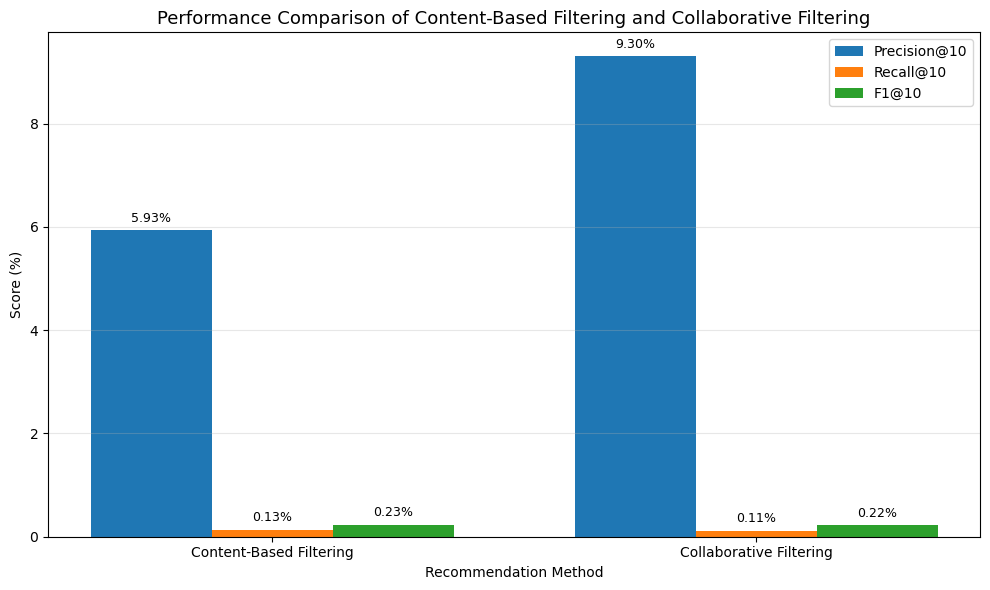

In [66]:
# ============================================================
# FIGURE 4.1
# PERFORMANCE COMPARISON OF CBF AND CF
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# FINAL EVALUATION RESULTS
# ------------------------------------------------------------

models = [
    "Content-Based Filtering",
    "Collaborative Filtering"
]

precision = [
    0.0593,
    0.0930
]

recall = [
    0.0013,
    0.0011
]

f1 = [
    0.0023,
    0.0022
]


# Convert scores to percentages
precision_pct = [x * 100 for x in precision]
recall_pct = [x * 100 for x in recall]
f1_pct = [x * 100 for x in f1]


# ------------------------------------------------------------
# CREATE CHART
# ------------------------------------------------------------

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width,
    precision_pct,
    width,
    label="Precision@10"
)

bars2 = ax.bar(
    x,
    recall_pct,
    width,
    label="Recall@10"
)

bars3 = ax.bar(
    x + width,
    f1_pct,
    width,
    label="F1@10"
)


# ------------------------------------------------------------
# LABELS AND TITLE
# ------------------------------------------------------------

ax.set_title(
    "Performance Comparison of Content-Based Filtering and Collaborative Filtering",
    fontsize=13
)

ax.set_xlabel(
    "Recommendation Method"
)

ax.set_ylabel(
    "Score (%)"
)

ax.set_xticks(x)

ax.set_xticklabels(
    models
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)


# ------------------------------------------------------------
# ADD VALUES ABOVE BARS
# ------------------------------------------------------------

for bars in [bars1, bars2, bars3]:

    for bar in bars:

        height = bar.get_height()

        ax.annotate(
            f"{height:.2f}%",
            xy=(
                bar.get_x() +
                bar.get_width() / 2,
                height
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )


# ------------------------------------------------------------
# LAYOUT
# ------------------------------------------------------------

plt.tight_layout()


# ------------------------------------------------------------
# SAVE HIGH-RESOLUTION IMAGE
# ------------------------------------------------------------

plt.savefig(
    "Figure_4_1_Model_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.show()